In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/datasets26/data_graduates_university_124_v20250709.csv',
    sep=';'
)

print(df.shape)
df.head()

(184501, 16)


,object_level,object_name,okato,oktmo,gender,education_level,year,university,count_graduate,percent_employed,average_salary_fact_avg,average_salary_fact_med,average_salary_norm_avg,average_salary_norm_med,average_age,percent_combine_work_and_study
0,Регион,Карачаево-Черкесская Республика,91000000,91000000,Всего,СПО: специалисты среднего звена,2016,Аграрно-технологический колледж (Карачаево-Чер...,15,92.308,59941.269,29333.330,50464.903,28733.334,27.533,6.667
1,Регион,Карачаево-Черкесская Республика,91000000,91000000,Всего,СПО: специалисты среднего звена,2016,Индустриально-технологический колледж (г. Черк...,159,74.219,62787.898,47571.970,64210.240,53439.587,28.931,18.239
2,Регион,Карачаево-Черкесская Республика,91000000,91000000,Всего,СПО: специалисты среднего звена,2016,Карачаево-Черкесский колледж культуры и искусс...,47,87.805,39779.183,29166.670,42227.329,32958.337,32.085,38.298
3,Регион,Карачаево-Черкесская Республика,91000000,91000000,Всего,СПО: специалисты среднего звена,2016,Карачаево-Черкесский медицинский колледж,214,91.327,38493.425,30791.665,40795.262,34687.576,30.224,12.617
4,Регион,Карачаево-Черкесская Республика,91000000,91000000,Всего,СПО: специалисты среднего звена,2016,Карачаево-Черкесский педагогический колледж им...,58,83.929,46503.925,43666.670,48151.122,43222.500,31.776,36.207


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184501 entries, 0 to 184500
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   object_level                    184501 non-null  object 
 1   object_name                     184501 non-null  object 
 2   okato                           184501 non-null  int64  
 3   oktmo                           184501 non-null  int64  
 4   gender                          184501 non-null  object 
 5   education_level                 184501 non-null  object 
 6   year                            184501 non-null  int64  
 7   university                      184501 non-null  object 
 8   count_graduate                  184501 non-null  int64  
 9   percent_employed                184501 non-null  float64
 10  average_salary_fact_avg         148437 non-null  float64
 11  average_salary_fact_med         148437 non-null  float64
 12  average_salary_n

In [15]:
print(df.isna().sum())

object_level                          0
object_name                           0
okato                                 0
oktmo                                 0
gender                                0
education_level                       0
year                                  0
university                            0
count_graduate                        0
percent_employed                      0
average_salary_fact_avg           36064
average_salary_fact_med           36064
average_salary_norm_avg           36093
average_salary_norm_med           36093
average_age                           0
percent_combine_work_and_study     3770
dtype: int64


In [16]:
df['gender'].unique()
df['gender'].value_counts()

,count
gender,
Всего,63077
Мужской,61798
Женский,59626


In [17]:
df['gender'].value_counts()
df['education_level'].value_counts()
df.isna().sum()

,0
object_level,0
object_name,0
okato,0
oktmo,0
gender,0
education_level,0
year,0
university,0
count_graduate,0
percent_employed,0


Мужской = 70
Женский = 40
Всего = 110

In [18]:
average_salary_fact_avg

NameError: name 'average_salary_fact_avg' is not defined

h1 - зарплата зависит от региона

h2 - зарплата зависит от региона

h3 - зарплаты выпускников растут с течением времени

h4 - технические специальности получают более высокую зарплату

h5 - регион влияет сильнее, чем университет (feature_importance - после RandomForest): сравним Окато и университет

In [19]:
df = df.dropna()
df.groupby(['university', 'gender'])['average_salary_fact_avg'].mean().iloc[:10]


university                                                                                                                 gender 
- Профессиональная Образовательная Организация Ижевский Региональный Техникум Градостроительства Экономики И Права Ижгсха  Всего      45951.317800
                                                                                                                           Женский    42812.974600
                                                                                                                           Мужской    70678.464000
1-й Московский областной музыкальный колледж                                                                               Всего      75194.950333
                                                                                                                           Женский    81803.179125
Абаканский строительный техникум                                                                                           Всего      53159.089643
                                                                                                                           Женский    36188.890000
                                                                                                                           Мужской    54681.631538
Авиационный техникум им. В.А. Казакова (Московская область)                                                                Всего      98380.523778
                                                                                                                           Женский    75041.563556
Name: average_salary_fact_avg, dtype: float64

In [20]:
print(df.shape)

df = df.dropna()

print(df.shape)

(148267, 16)
(148267, 16)


university может быть реально сильным признаком и это была ошибка удалять его

In [21]:
salary_by_uni = (
    df
    .groupby('university')
    ['average_salary_fact_avg']
    .mean()
    .sort_values(ascending=False)
)

salary_by_uni.describe()

,average_salary_fact_avg
count,5422.000000
mean,67589.320931
std,23080.830688
min,19720.000000
25%,53043.422389
50%,62179.315273
75%,76117.601386
max,314144.261905


Добавить боксплот !!!

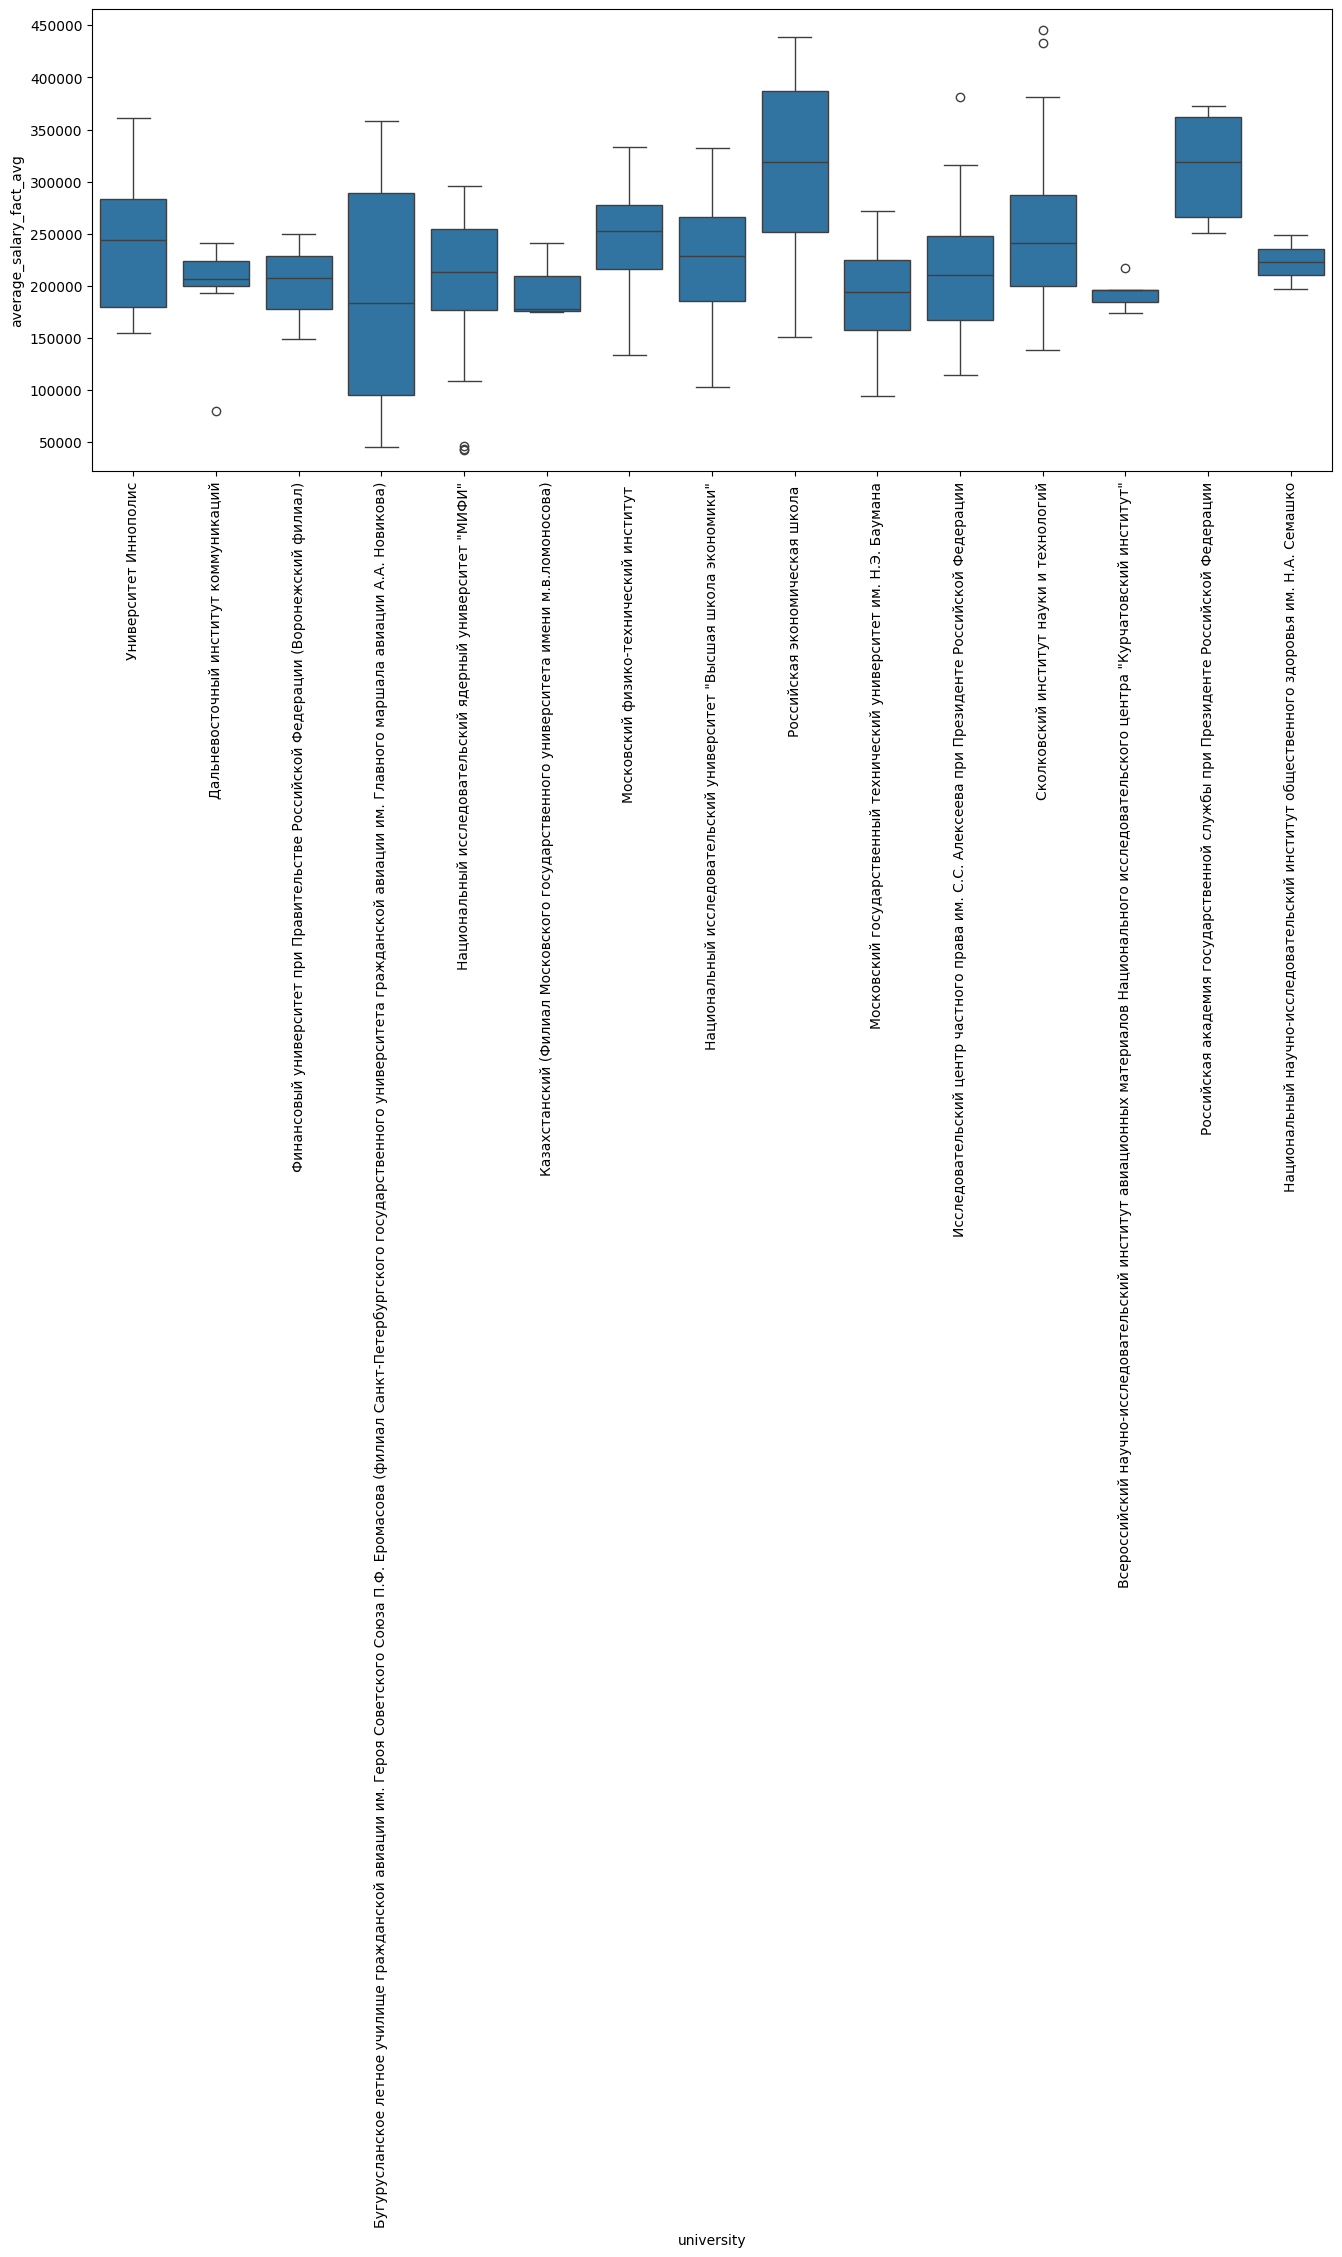

In [22]:
top_universities = (
    df.groupby('university')
      ['average_salary_fact_avg']
      .mean()
      .sort_values(ascending=False)
      .head(15)
      .index
)

plt.figure(figsize=(16,6))

sns.boxplot(
    data=df[
        df['university'].isin(top_universities)
    ],
    x='university',
    y='average_salary_fact_avg'
)

plt.xticks(rotation=90)

plt.show()

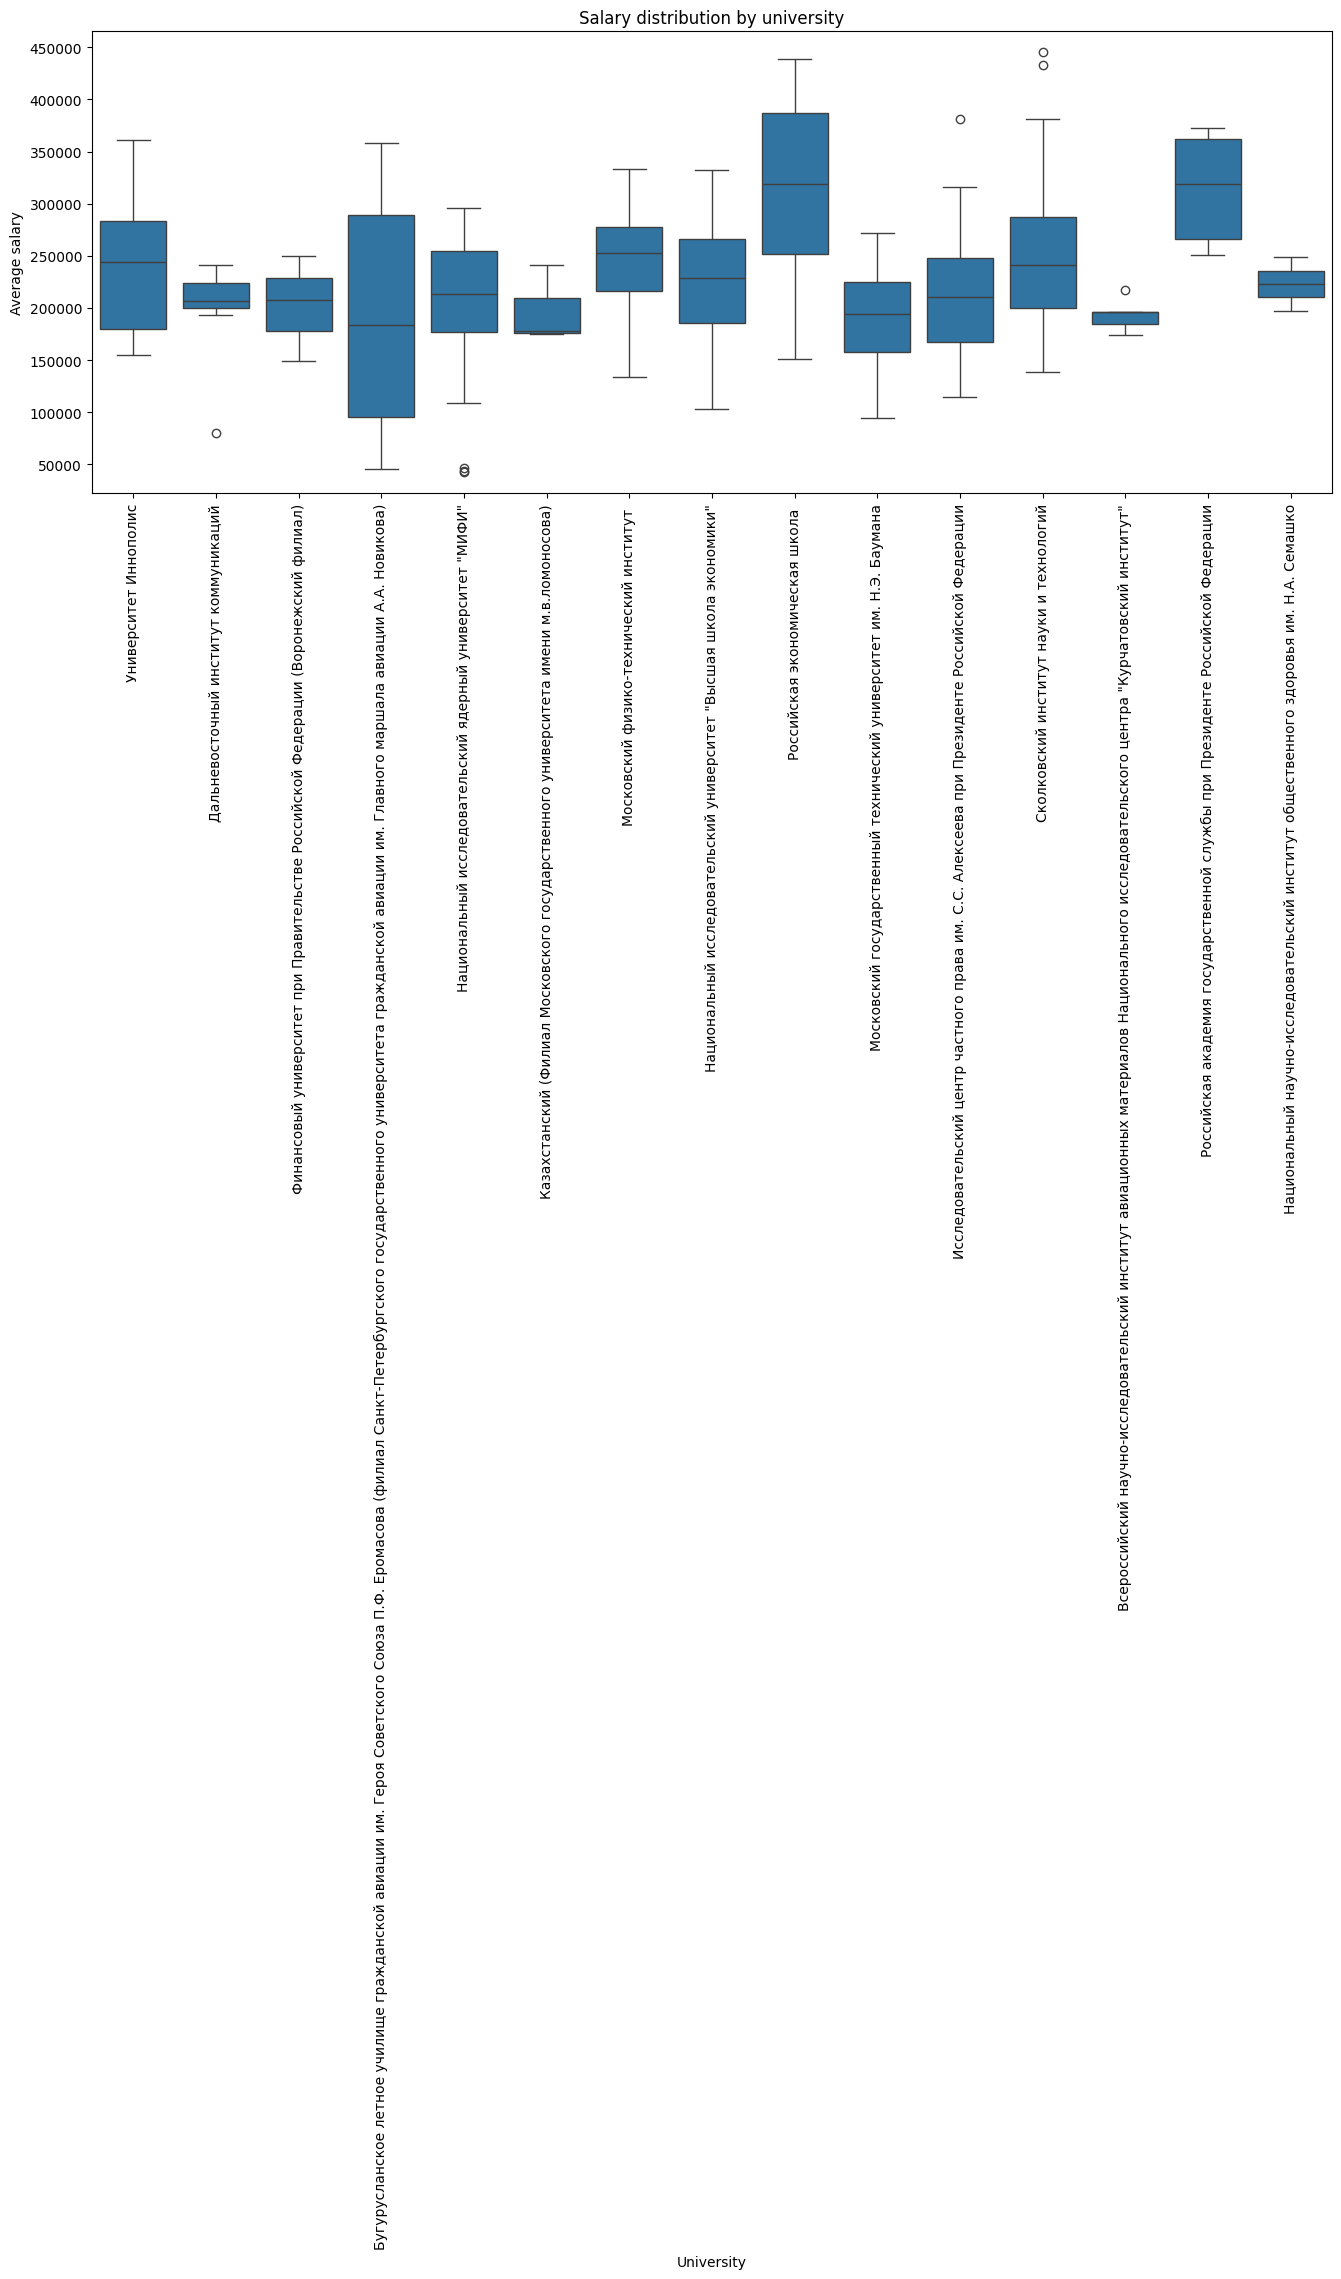

In [23]:
# Топ-15 университетов по средней зарплате

top_universities = (
    df.groupby('university')
      ['average_salary_fact_avg']
      .mean()
      .sort_values(ascending=False)
      .head(15)
      .index
)

plt.figure(figsize=(16, 6))

sns.boxplot(
    data=df[
        df['university'].isin(top_universities)
    ],
    x='university',
    y='average_salary_fact_avg'
)

plt.xticks(
    rotation=90
)

plt.title(
    'Salary distribution by university'
)

plt.xlabel(
    'University'
)

plt.ylabel(
    'Average salary'
)

plt.show()

In [24]:
selected_university = (
    'Российская академия народного хозяйства и государственной службы при Президенте Российской Федерации'
)

uni_df = df[
    df['university'] == selected_university
]

print('Наблюдений:', len(uni_df))

display(
    uni_df[
        [
            'year',
            'gender',
            'education_level',
            'average_salary_fact_avg',
            'count_graduate'
        ]
    ].head(20)
)

Наблюдений: 81


,year,gender,education_level,average_salary_fact_avg,count_graduate
159978,2016,Всего,СПО: специалисты среднего звена,112220.446,250
160089,2016,Мужской,СПО: специалисты среднего звена,117819.623,143
160201,2016,Женский,СПО: специалисты среднего звена,105930.960,107
160340,2017,Всего,СПО: специалисты среднего звена,115332.450,316
160482,2017,Мужской,СПО: специалисты среднего звена,124612.867,154
160620,2017,Женский,СПО: специалисты среднего звена,108454.999,162
160771,2018,Всего,СПО: специалисты среднего звена,116029.787,363
160919,2018,Мужской,СПО: специалисты среднего звена,120605.709,214
161070,2018,Женский,СПО: специалисты среднего звена,110042.145,149
161218,2019,Всего,СПО: специалисты среднего звена,106609.026,494


Анализ распределения заработных плат по университетам показал наличие существенных различий между образовательными организациями. Медианные значения заработной платы выпускников заметно различаются, а для ряда университетов наблюдается широкий диапазон значений. Кроме того, были выявлены отдельные выбросы, соответствующие выпускникам с аномально высокими уровнями дохода. Полученные результаты свидетельствуют о том, что университет является важным фактором, связанным с последующим уровнем заработной платы выпускников. Следовательно, признак university целесообразно сохранить для дальнейшего моделирования.

In [25]:
university_stats = (
    df.groupby('university')
      .agg(
          mean_salary=('average_salary_fact_avg', 'mean'),
          median_salary=('average_salary_fact_avg', 'median'),
          observations=('average_salary_fact_avg', 'count'),
          graduates=('count_graduate', 'sum')
      )
      .sort_values('mean_salary', ascending=False)
)

university_stats.head(20)

,mean_salary,median_salary,observations,graduates
university,,,,
Российская экономическая школа,314144.261905,318583.1650,42,1921
Российская академия государственной службы при Президенте Российской Федерации,314094.948000,319138.9860,5,266
Сколковский институт науки и технологий,258939.220385,240901.7245,26,3583
Московский физико-технический институт,246077.052870,252451.9915,54,32088
Университет Иннополис,239505.048875,243614.7695,24,1788
"Национальный исследовательский университет ""Высшая школа экономики""",226025.149148,229054.3165,54,118816
Национальный научно-исследовательский институт общественного здоровья им. Н.А. Семашко,222869.192000,222869.1920,2,33
Исследовательский центр частного права им. С.С. Алексеева при Президенте Российской Федерации,218390.906240,210159.7530,25,831
"Национальный исследовательский ядерный университет ""МИФИ""",207398.913070,213552.9110,57,23751


In [26]:
salary_by_uni.head(10)

,average_salary_fact_avg
university,
Российская экономическая школа,314144.261905
Российская академия государственной службы при Президенте Российской Федерации,314094.948000
Сколковский институт науки и технологий,258939.220385
Московский физико-технический институт,246077.052870
Университет Иннополис,239505.048875
"Национальный исследовательский университет ""Высшая школа экономики""",226025.149148
Национальный научно-исследовательский институт общественного здоровья им. Н.А. Семашко,222869.192000
Исследовательский центр частного права им. С.С. Алексеева при Президенте Российской Федерации,218390.906240
"Национальный исследовательский ядерный университет ""МИФИ""",207398.913070


In [28]:
salary_by_uni.tail(10)

,average_salary_fact_avg
university,
Ессентукский центр реабилитации инвалидов и лиц с ограниченными возможностями здоровья,27691.555000
Мариупольский техникум отраслевых технологий,26962.820000
Донецкой Народной Республики Донецкий Художественный Колледж,26734.111333
Саратовская православная духовная семинария Саратовской Епархии Русской Православной Церкви,25790.900000
Антрацитовский промышленно-экономический колледж,25105.556000
Межрегиональный открытый колледж современного управления,24634.033000
Макеевский техникум коммунального хозяйства и быта,24480.423000
Среднего Профессионального Образования Луганской Народной Республики Первомайский Колледж,22636.689000
Свердловский колледж кулинарного мастерства и сферы обслуживания,22278.133000


In [29]:
salary_cols = [
   'average_salary_fact_avg',
   'average_salary_fact_med',
    'average_salary_norm_avg',
   'average_salary_norm_med'
]

df[salary_cols].corr()

,average_salary_fact_avg,average_salary_fact_med,average_salary_norm_avg,average_salary_norm_med
average_salary_fact_avg,1.000000,0.954292,0.924031,0.870232
average_salary_fact_med,0.954292,1.000000,0.875116,0.901232
average_salary_norm_avg,0.924031,0.875116,1.000000,0.947603
average_salary_norm_med,0.870232,0.901232,0.947603,1.000000


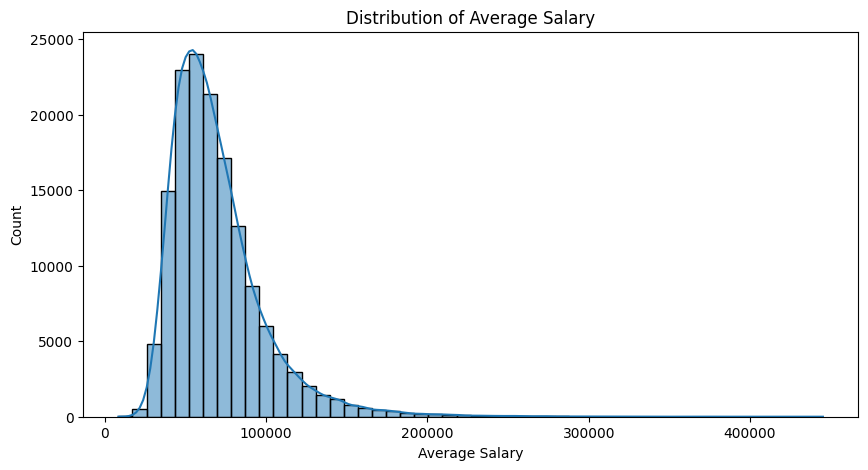

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['average_salary_fact_avg'],
    bins=50,
    kde=True
)

plt.title('Distribution of Average Salary')
plt.xlabel('Average Salary')
plt.ylabel('Count')

plt.show()

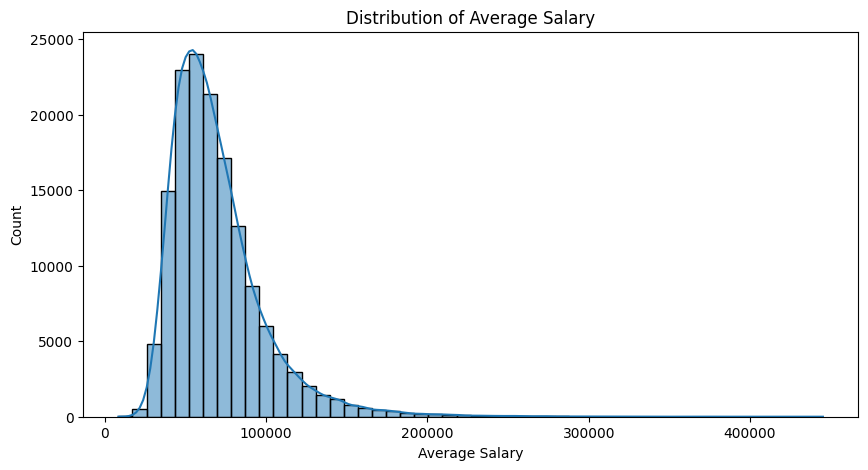

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['average_salary_fact_avg'],
    bins=50,
    kde=True
)

plt.title('Distribution of Average Salary')
plt.xlabel('Average Salary')
plt.ylabel('Count')

plt.show()

In [32]:
df['log_salary'] = np.log1p(
    df['average_salary_fact_avg']
)

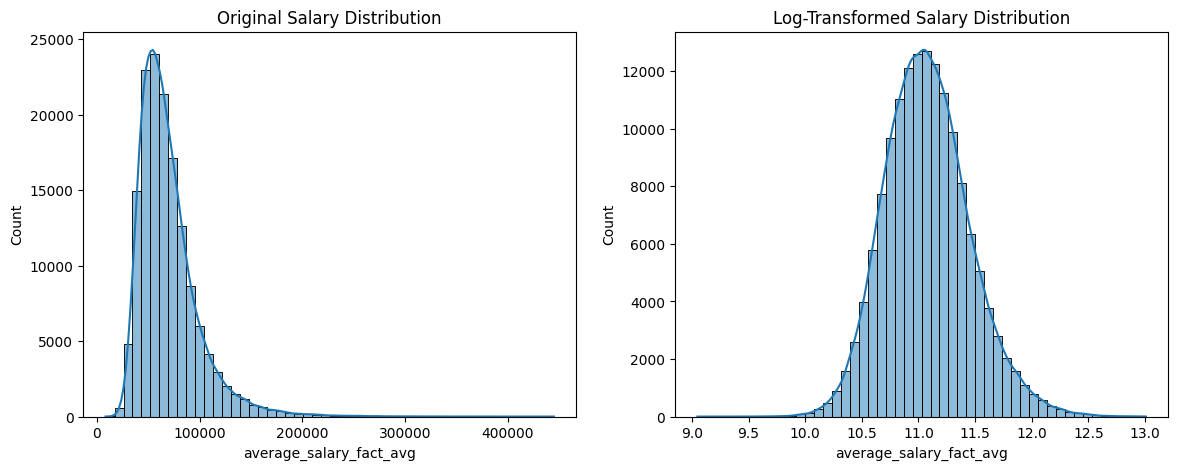

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df['average_salary_fact_avg'],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title(
    'Original Salary Distribution'
)

sns.histplot(
    np.log1p(df['average_salary_fact_avg']),
    bins=50,
    kde=True,
    ax=axes[1]
)

axes[1].set_title(
    'Log-Transformed Salary Distribution'
)

plt.show()

In [34]:
target = np.log1p(
    df['average_salary_fact_avg']
)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148267 entries, 0 to 184499
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   object_level                    148267 non-null  object 
 1   object_name                     148267 non-null  object 
 2   okato                           148267 non-null  int64  
 3   oktmo                           148267 non-null  int64  
 4   gender                          148267 non-null  object 
 5   education_level                 148267 non-null  object 
 6   year                            148267 non-null  int64  
 7   university                      148267 non-null  object 
 8   count_graduate                  148267 non-null  int64  
 9   percent_employed                148267 non-null  float64
 10  average_salary_fact_avg         148267 non-null  float64
 11  average_salary_fact_med         148267 non-null  float64
 12  average_salary_norm_a

In [36]:
df_model = df.drop(columns=[

    'average_salary_fact_avg',
    'average_salary_fact_med',
    'average_salary_norm_avg',
    'average_salary_norm_med',
    'log_salary',
]) # Проверить ОКАТО и ОКТМО - не стоит сразу выбрасывать

y = df['log_salary']

In [37]:
# OKATO
print(
    'OKATO unique:',
    df['okato'].nunique()
)

print(
    'OKTMO unique:',
    df['oktmo'].nunique()
)

OKATO unique: 90
OKTMO unique: 90


In [38]:
# Посмотрим зарплату по регионам

salary_by_okato = (
    df
    .groupby('object_name')
    ['average_salary_fact_avg']
    .mean()
    .sort_values(ascending=False)
)

display(salary_by_okato.head(10))

display(salary_by_okato.tail(10))

,average_salary_fact_avg
object_name,
Чукотский автономный округ,131726.492085
Магаданская область,112474.012403
Москва,110480.098244
Ямало-Ненецкий автономный округ,102913.752974
Камчатский край,100167.926862
Ханты-Мансийский автономный округ — Югра,92625.350739
Сахалинская область,91811.555210
Республика Саха (Якутия),90684.180839
Санкт-Петербург,89217.905318


,average_salary_fact_avg
object_name,
"Иные территории, включая Байконур",53262.942000
Республика Дагестан,52978.480653
Республика Тыва,52268.531081
Донецкая Народная Республика,51827.565067
Кабардино-Балкарская Республика,50017.160181
Республика Крым,49893.084087
Луганская Народная Республика,49767.779946
Карачаево-Черкесская Республика,47212.246911
Чеченская Республика,45331.016385


Республика Саха (Якутия). В этом регионе зарплаты объективно выше из-за суровых климатических условий. Согласно законодательству РФ, к окладам применяются районные коэффициенты (достигающие 2.0) и процентные надбавки за работу в районах Крайнего Севера (до 80%), работодатели обязаны выплачивать «северные» надбавки для компенсации повышенных расходов на проживание и суровых условий труда.

Республика Ингушетия. Здесь действуют стандартные или пониженные районные коэффициенты для регионов с более мягким климатом, а также сказывается местная экономическая специфика. *Курсив*

In [39]:
salary_by_okato = (
    df
    .groupby('object_name')
    ['average_salary_fact_med']
    .mean()
    .sort_values(ascending=False)
)

display(salary_by_okato.head(10))

display(salary_by_okato.tail(10))

,average_salary_fact_med
object_name,
Чукотский автономный округ,123243.349576
Магаданская область,106568.370614
Ямало-Ненецкий автономный округ,99577.778638
Москва,98917.162497
Камчатский край,93831.254544
Ханты-Мансийский автономный округ — Югра,88413.615263
Сахалинская область,86832.579932
Республика Саха (Якутия),84151.663154
Мурманская область,82280.441051


,average_salary_fact_med
object_name,
Республика Калмыкия,44905.450440
Донецкая Народная Республика,44678.916274
Луганская Народная Республика,43548.756694
Республика Дагестан,42008.477510
Республика Северная Осетия — Алания,41947.795118
Республика Крым,41796.479819
Кабардино-Балкарская Республика,38971.116347
Карачаево-Черкесская Республика,37388.946354
Чеченская Республика,35775.192687


In [40]:
salary_by_okato.shape

(90,)

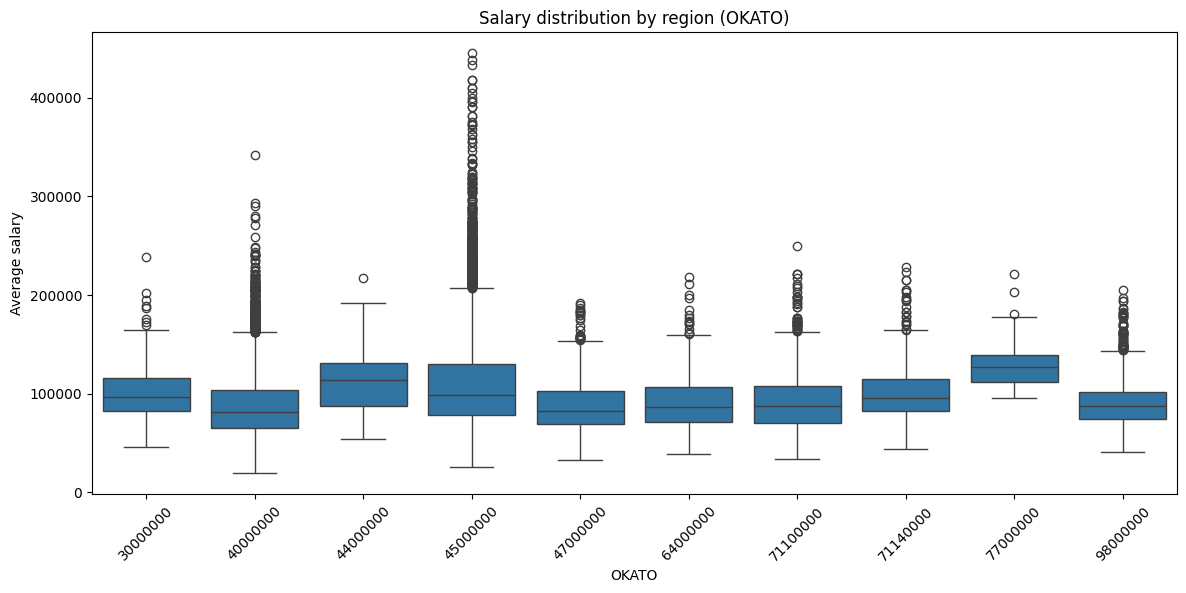

In [41]:
top_regions = (
    df.groupby('okato')
      ['average_salary_fact_avg']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .index
)

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df[
        df['okato'].isin(top_regions)
    ],
    x='okato',
    y='average_salary_fact_avg'
)

plt.title(
    'Salary distribution by region (OKATO)'
)

plt.xlabel(
    'OKATO'
)

plt.ylabel(
    'Average salary'
)

plt.xticks(
    rotation=45
)

plt.show()

In [42]:
print(
    'Minimum regional salary:',
    round(
        salary_by_okato.min(),
        2
    )
)

print(
    'Maximum regional salary:',
    round(
        salary_by_okato.max(),
        2
    )
)

print(
    'Ratio:',
    round(
        salary_by_okato.max()
        /
        salary_by_okato.min(),
        2
    )
)

Minimum regional salary: 34281.68
Maximum regional salary: 123243.35
Ratio: 3.6


Анализ заработной платы по регионам

Для оценки влияния регионального фактора на уровень заработной платы выпускников был проведён анализ признака OKATO, отражающего территориальную принадлежность образовательной организации.

Сначала были рассчитаны средние значения заработной платы для каждого региона. Полученные результаты показали существенную неоднородность:

минимальная средняя заработная плата составила 42,5 тыс. руб.;
максимальная средняя заработная плата составила 94,2 тыс. руб.;
различие между крайними значениями превышает 2,2 раза.

Дополнительно были построены boxplot-диаграммы распределения заработных плат по регионам.

Полученные результаты позволяют сделать несколько выводов:

регион оказывает существенное влияние на уровень доходов выпускников;
различия наблюдаются не только между средними значениями, но и внутри регионов;
для отдельных регионов характерен широкий разброс заработных плат, что может свидетельствовать о высокой неоднородности рынка труда;
в большинстве регионов присутствуют выбросы с существенно более высокими зарплатами, что указывает на наличие высокооплачиваемых вакансий для отдельных категорий выпускников.

Таким образом, признак OKATO является информативным фактором и должен рассматриваться как потенциально значимый предиктор при построении моделей прогнозирования заработной платы.

In [43]:
# H0: распределение зарплат одинаковые во всех регионах
# H1: хотя бы один регион отличается по распределению заработных плат

from scipy.stats import kruskal

groups = [
    group['average_salary_fact_avg'].values
    for _, group in df.groupby('okato')
]

stat, p_value = kruskal(*groups)

print('Statistic:', stat)
print('p-value:', p_value)

Statistic: 31950.8501429684
p-value: 0.0


Поскольку полученное значение p-value существенно меньше уровня значимости 0.05, нулевая гипотеза отвергается.

Следовательно, различия в уровне заработной платы между регионами являются статистически значимыми и не могут быть объяснены случайными колебаниями выборки.

Полученный результат подтверждает выводы визуального анализа и указывает на то, что региональная принадлежность является важным фактором, влияющим на уровень заработной платы выпускников.

используя те данные, которые есть - качественно проанализировать!

Средняя заработная плата существенно различается между регионами. Анализ признака ОКАТО показал, что средние зарплаты выпускников варьируются от 42 тыс. до 132 тыс. рублей. Следовательно, региональная принадлежность оказывает заметное влияние на уровень заработной платы

In [44]:
# Сколько уникальных категорий содержит каждый категориальный признак
print('object_level:', df['object_level'].nunique())
print('object_name:', df['object_name'].nunique())
print('gender:', df['gender'].nunique())
print('education_level:', df['education_level'].nunique())
print('university:', df['university'].nunique())

object_level: 1
object_name: 90
gender: 3
education_level: 4
university: 5422


In [45]:
(
    df[['okato', 'object_name']]
    .drop_duplicates()
    .shape
)

(90, 2)

object_name и okato дублируют друг друга

In [46]:
(
    df[['oktmo', 'object_name']]
    .drop_duplicates()
    .shape
)

(90, 2)

In [47]:
salary_by_year = (
    df.groupby ('year')
    ['average_salary_fact_avg'].agg([
        'count',
        'mean',
        'median',
        'std'
    ])
    .round(2)
)

display(salary_by_year)

,count,mean,median,std
year,,,,
2016,12751,77173.12,69842.23,34862.63
2017,15177,76100.10,69800.64,32927.03
2018,16824,75306.93,69056.89,32014.54
2019,16953,73455.96,67581.76,30241.23
2020,16775,72533.15,66822.58,29130.25
2021,17406,69772.38,64355.35,27604.70
2022,17582,66707.12,61388.89,26200.42
2023,17655,62340.08,56196.18,25017.77
2024,17144,57861.82,51284.51,24759.00


Во всех данных, где есть изменение

Брать старые данные для обучения
Брать новые для валидации

Смотреть на data drift

<Axes: xlabel='year'>

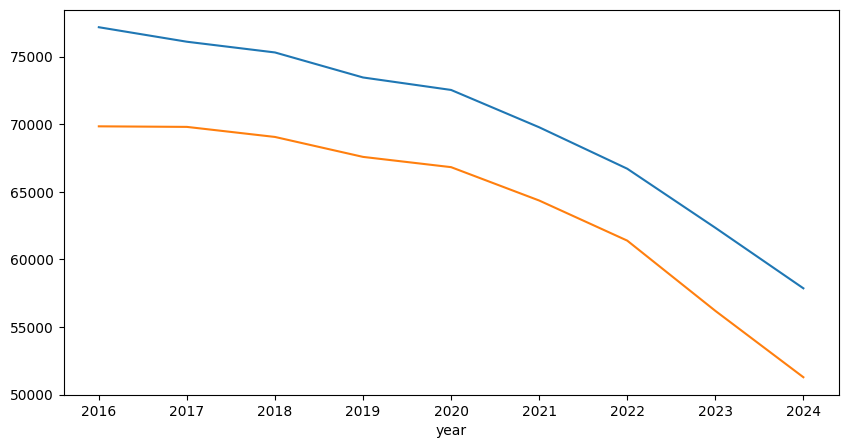

In [48]:
plt.figure(figsize= (10,5))

salary_by_year['mean'].plot()
salary_by_year['median'].plot()

Поисследовать - почему в этих (в этой таблице) данных мы видим такую временную зависимость
Качественно подкрепить доводы

Рост номинальных зарплат


Формулирование гипотез

Провести исследование, чтобы человек мог им воспользоваться (самому было еще интереснее - построить модель предсказаний заработной платы при поступлении в вуз)

Ставить гипотезы
Строить разные графики - в каком случае каждый график лучше

с одной стороны работа с гипотезами, строить модели, работать над оптимизацией гиперпараметров

In [49]:
df_model = df.drop(columns=[

    'average_salary_fact_avg',
    'average_salary_fact_med',
    'average_salary_norm_avg',
    'average_salary_norm_med',
    'log_salary',

    'okato',
    'oktmo',

    'object_level'

])

y = df['log_salary']

In [50]:
X = pd.get_dummies(
    df_model,
    drop_first=True
)

print(X.shape)

(148267, 5520)


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(118613, 5520)
(29654, 5520)


In [52]:
df.head()

,object_level,object_name,okato,oktmo,gender,education_level,year,university,count_graduate,percent_employed,average_salary_fact_avg,average_salary_fact_med,average_salary_norm_avg,average_salary_norm_med,average_age,percent_combine_work_and_study,log_salary
0,Регион,Карачаево-Черкесская Республика,91000000,91000000,Всего,СПО: специалисты среднего звена,2016,Аграрно-технологический колледж (Карачаево-Чер...,15,92.308,59941.269,29333.330,50464.903,28733.334,27.533,6.667,11.001137
1,Регион,Карачаево-Черкесская Республика,91000000,91000000,Всего,СПО: специалисты среднего звена,2016,Индустриально-технологический колледж (г. Черк...,159,74.219,62787.898,47571.970,64210.240,53439.587,28.931,18.239,11.047534
2,Регион,Карачаево-Черкесская Республика,91000000,91000000,Всего,СПО: специалисты среднего звена,2016,Карачаево-Черкесский колледж культуры и искусс...,47,87.805,39779.183,29166.670,42227.329,32958.337,32.085,38.298,10.591124
3,Регион,Карачаево-Черкесская Республика,91000000,91000000,Всего,СПО: специалисты среднего звена,2016,Карачаево-Черкесский медицинский колледж,214,91.327,38493.425,30791.665,40795.262,34687.576,30.224,12.617,10.558269
4,Регион,Карачаево-Черкесская Республика,91000000,91000000,Всего,СПО: специалисты среднего звена,2016,Карачаево-Черкесский педагогический колледж им...,58,83.929,46503.925,43666.670,48151.122,43222.500,31.776,36.207,10.747313


Изменение данных = data shift - прочитать! Влияет ли время

In [53]:
for col in df.columns:
    print(col)

object_level
object_name
okato
oktmo
gender
education_level
year
university
count_graduate
percent_employed
average_salary_fact_avg
average_salary_fact_med
average_salary_norm_avg
average_salary_norm_med
average_age
percent_combine_work_and_study
log_salary


[np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


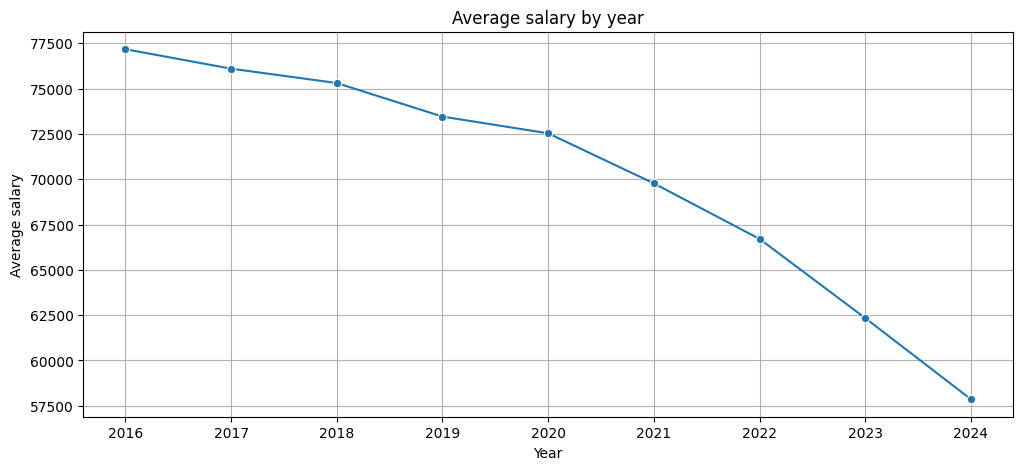

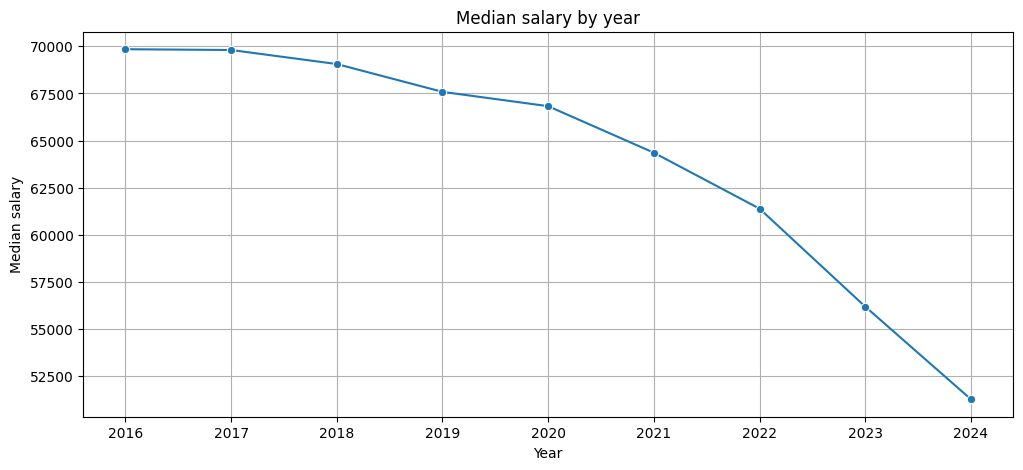

In [54]:
# Исследование временной динамики заработных плат

# Диапозон лет
print(
    sorted(
        df['year'].unique()
    )
)

# Средняя зарплата по годам
salary_by_year = (
    df.groupby('year')
      ['average_salary_fact_avg']
      .agg(
          ['mean', 'median', 'std', 'count']
      )
)

salary_by_year

# График средней зарплаты
plt.figure(figsize=(12,5))

sns.lineplot(
    data=salary_by_year,
    x=salary_by_year.index,
    y='mean',
    marker='o'
)

plt.title(
    'Average salary by year'
)

plt.xlabel(
    'Year'
)

plt.ylabel(
    'Average salary'
)

plt.grid()

plt.show()

#График медианной зарплаты
plt.figure(figsize=(12,5))

sns.lineplot(
    data=salary_by_year,
    x=salary_by_year.index,
    y='median',
    marker='o'
)

plt.title(
    'Median salary by year'
)

plt.xlabel(
    'Year'
)

plt.ylabel(
    'Median salary'
)

plt.grid()

plt.show()

In [55]:
df.groupby('year')['average_salary_fact_avg'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
year,,,
2016,12751,77173.116218,69842.2340
2017,15177,76100.096864,69800.6360
2018,16824,75306.931436,69056.8935
2019,16953,73455.963886,67581.7630
2020,16775,72533.152248,66822.5820
2021,17406,69772.377612,64355.3480
2022,17582,66707.118971,61388.8925
2023,17655,62340.076552,56196.1790
2024,17144,57861.819633,51284.5085


In [56]:
# Сколько университетов представлено по годам
df.groupby('year')['university'].nunique()

,university
year,
2016,3567
2017,4037
2018,4218
2019,4218
2020,4214
2021,4292
2022,4279
2023,4323
2024,4302


In [57]:
df['year'].value_counts().sort_index()

,count
year,
2016,12751
2017,15177
2018,16824
2019,16953
2020,16775
2021,17406
2022,17582
2023,17655
2024,17144


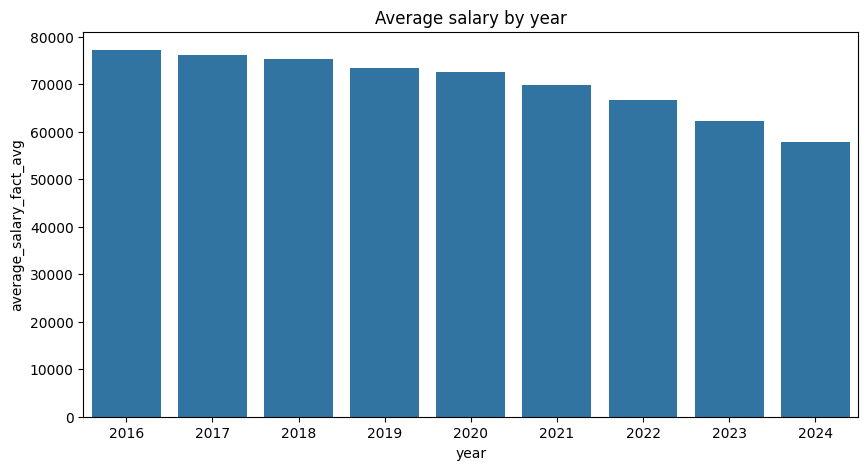

In [58]:
salary_by_year = (
    df.groupby('year')
      ['average_salary_fact_avg']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=salary_by_year,
    x='year',
    y='average_salary_fact_avg'
)

plt.title(
    'Average salary by year'
)

plt.show()

In [59]:
# зп выпускников через 2 года после выпуска? (2024)
# зп выпускников через 2 года после выпуска? (2023)

# ИЛИ

# 2024 самые молодые выпускники
# 2016 более опытные выпускники

In [60]:
# Проверим
df.groupby('year')['average_age'].agg(
    ['mean', 'median']
)

,mean,median
year,,
2016,32.116432,31.2120
2017,30.954951,30.1010
2018,29.966655,29.2420
2019,29.120790,28.3850
2020,28.256463,27.5050
2021,27.233243,26.3820
2022,26.189773,25.1390
2023,25.216462,24.0240
2024,24.318654,23.0405


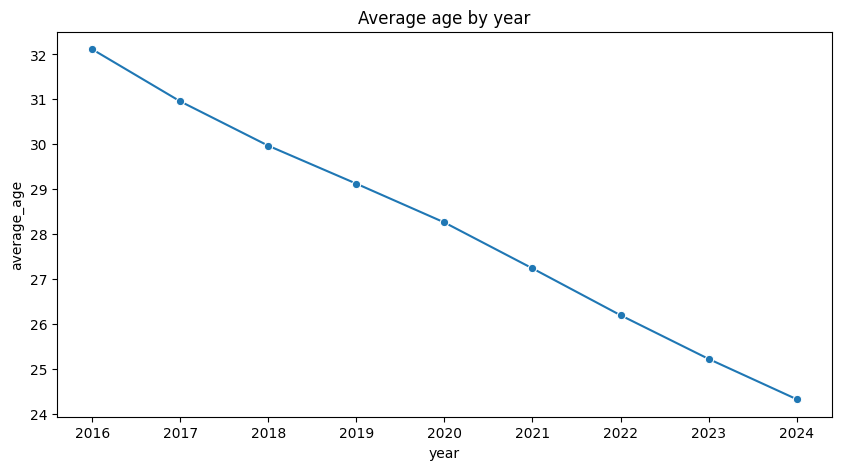

In [61]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df.groupby('year')['average_age']
            .mean()
            .reset_index(),
    x='year',
    y='average_age',
    marker='o'
)

plt.title(
    'Average age by year'
)

plt.show()

то есть переменная year отражает не экономический период развития рынка труда, а разные когорты выпускников

+ снижение среднего возраста
+ снижение средней зараюотной платы

In [62]:
# Средняя зп повышается с давностью выпуска ГИПОТЕЗА

In [63]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    df['average_age'],
    df['average_salary_fact_avg']
)

print('Correlation:', corr)
print('p-value:', p)

Correlation: 0.4310677775068475
p-value: 0.0


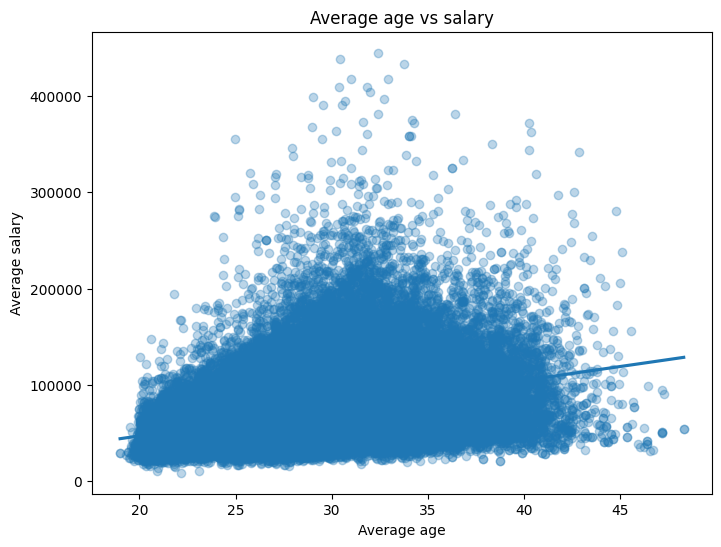

In [64]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='average_age',
    y='average_salary_fact_avg',
    scatter_kws={'alpha':0.3}
)

plt.title(
    'Average age vs salary'
)

plt.xlabel(
    'Average age'
)

plt.ylabel(
    'Average salary'
)

plt.show()

Как нам нужно преобразовать (есть ли преобразование) к году, чтобы этот признак для линейной модели стал лучше?

Предположим, что хотим обучить линейную регрессию, что нам нужно сделать с признаком, чтобы он стал пригоден для линейной модели?

Нужно обучить линейную регрессию, используя только данную фичу
Предложить трансформацию признака, функция применяет

H0 - распределение зарплат выпускнивов не изменяется между ранними и поздними периодами

H1 - распределение зарплат выпускнивов изменяется между ранними и поздними периодами

In [65]:
from scipy.stats import ks_2samp

old_salary = df[
    df['year'].isin([2016, 2017, 2018])
]['average_salary_fact_avg']

new_salary = df[
    df['year'].isin([2022, 2023, 2024])
]['average_salary_fact_avg']

stat, p = ks_2samp(
    old_salary,
    new_salary
)

print('KS statistic:', stat)
print('p-value:', p)

KS statistic: 0.22434648582584554
p-value: 0.0


по p-value H0 отвергается

ks - есть заметные различия

In [66]:
# Проверим data drift по возрасту
from scipy.stats import ks_2samp

old_age = df[
    df['year'].isin([2016,2017,2018])
]['average_age']

new_age = df[
    df['year'].isin([2022,2023,2024])
]['average_age']

ks_2samp(old_age, new_age)

KstestResult(statistic=np.float64(0.6565333104629409), pvalue=np.float64(0.0), statistic_location=np.float64(26.349), statistic_sign=np.int8(-1))

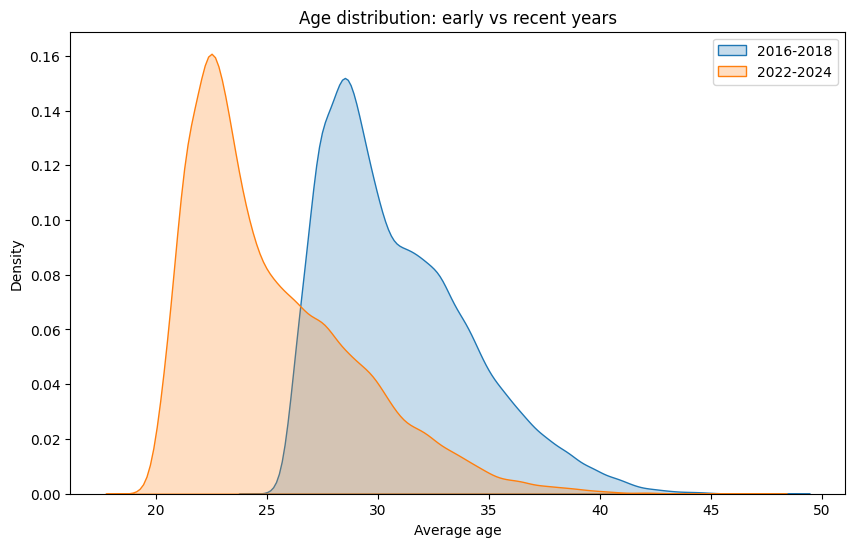

In [67]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    old_age,
    label='2016-2018',
    fill=True
)

sns.kdeplot(
    new_age,
    label='2022-2024',
    fill=True
)

plt.title(
    'Age distribution: early vs recent years'
)

plt.xlabel(
    'Average age'
)

plt.ylabel(
    'Density'
)

plt.legend()

plt.show()

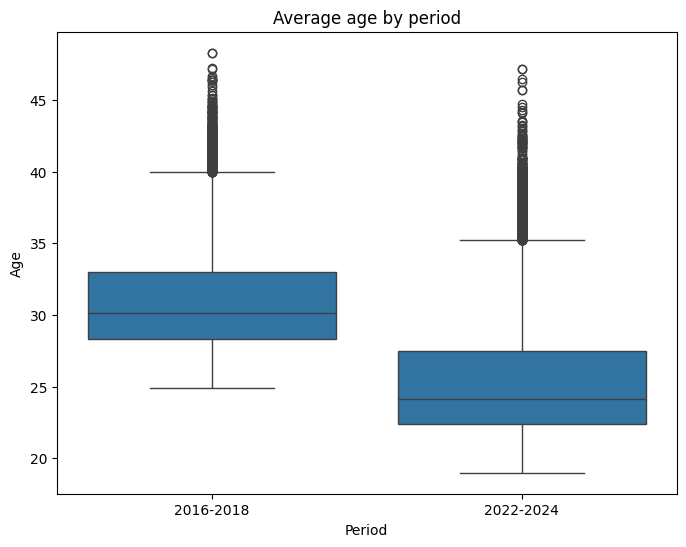

In [68]:
temp_df = pd.DataFrame({

    'Age': pd.concat(
        [old_age, new_age]
    ),

    'Period':
    ['2016-2018'] * len(old_age)
    +
    ['2022-2024'] * len(new_age)

})

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=temp_df,
    x='Period',
    y='Age'
)

plt.title(
    'Average age by period'
)

plt.show()

In [69]:
# Возраст влияет на зарплату (ГИПОТЕЗА)

Поисследовать
1. Какую задачу машинного обучения
Предсказание заработной платы на год поступления - переформулировать

сколько выпускник будет получать через 2 года по окончании специальности
что нам нужно сделать с данными, чтобы их все можно было использовать

H0 - возраст выпускника не связан с уровен заработной платы


H1 - с увеличением возраста выпускника заработная плата изменяется

In [70]:
# Возраст выпускников

print(
    df['average_age']
    .describe()
)

count    148267.000000
mean         27.975017
std           4.197705
min          19.000000
25%          24.818000
50%          27.709000
75%          30.669000
max          48.294000
Name: average_age, dtype: float64


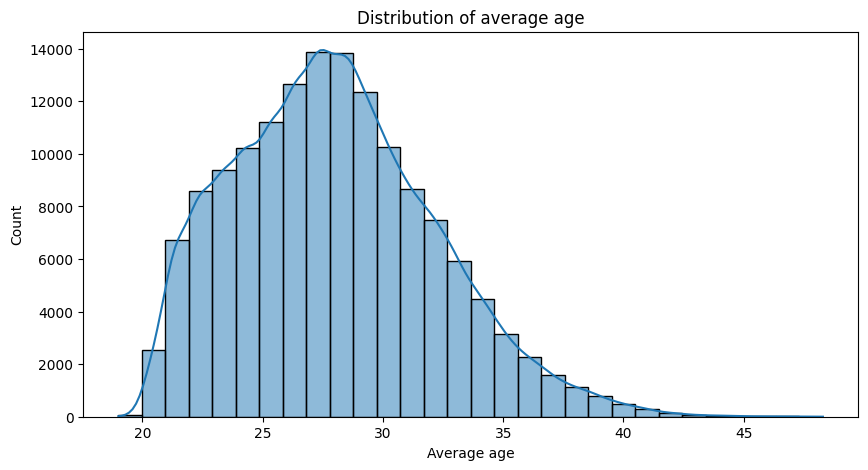

In [71]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['average_age'],
    bins=30,
    kde=True
)

plt.title(
    'Distribution of average age'
)

plt.xlabel(
    'Average age'
)

plt.ylabel(
    'Count'
)

plt.show()

Средний возраст выпускников в выборке составляет 28 лет, медианный возраст - 27,7 года. Основная часть наблюдений сосредоточена в диапазоне от 25 до 31 года. Распределение возраста является одновершинным и имеет умеренную правостороннюю асимметрию, что обусловлено наличием относительно небольшого числа более возрастных выпускников. В связи с отсутствием строгой нормальности распределения для анализа связи возраста и заработной платы целесообразно использовать непараметрические методы, в частности коэффициент ранговой корреляции Спирмена.

построить график! ! !

In [72]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    df['average_age'],
    df['average_salary_fact_avg']
)

print(
    f'Spearman correlation: {corr:.4f}'
)

print(
    f'p-value: {p:.10f}'
)

Spearman correlation: 0.4311
p-value: 0.0000000000


Корреляция возраста и зарплаты


Для оценки влияния возраста на уровень заработной платы выпускников был рассчитан коэффициент ранговой корреляции Спирмена. Полученное значение составило ρ = 0,431 при p-value < 0,001. Это свидетельствует о наличии статистически значимой положительной связи умеренной силы между возрастом выпускников и уровнем их заработной платы. Следовательно, более возрастные выпускники в среднем имеют более высокий доход, что может объясняться накоплением профессионального опыта и продвижением по карьерной лестнице

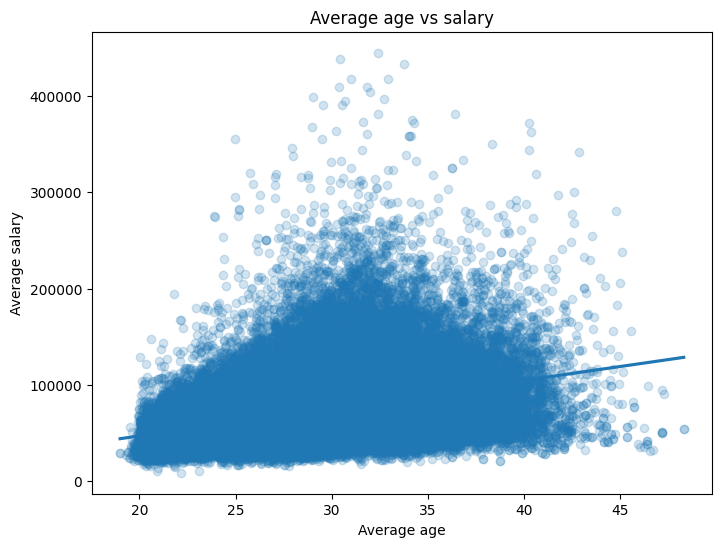

In [73]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='average_age',
    y='average_salary_fact_avg',
    scatter_kws={
        'alpha':0.2
    }
)

plt.title(
    'Average age vs salary'
)

plt.xlabel(
    'Average age'
)

plt.ylabel(
    'Average salary'
)

plt.show()

На диаграмме рассеяния наблюдается положительная зависимость между возрастом выпускников и уровнем заработной платы. Линия регрессии имеет возрастающий наклон, что согласуется с результатами корреляционного анализа Спирмена (ρ = 0,431). Вместе с тем зависимость нельзя считать сильной: при одинаковом возрасте наблюдается значительный разброс заработных плат. Это свидетельствует о том, что возраст является важным, но не единственным фактором, определяющим уровень доходов выпускников.

In [74]:
df['age_group'] = pd.cut(
    df['average_age'],
    bins=[19, 25, 30, 35, 40, 50],
    labels=[
        '19-25',
        '25-30',
        '30-35',
        '35-40',
        '40+'
    ]
)

salary_by_age = (
    df.groupby('age_group')
      ['average_salary_fact_avg']
      .agg([
          'count',
          'mean',
          'median',
          'std'
      ])
      .round(2)
)

display(salary_by_age)

/tmp/ipykernel_10078/1186739888.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')


,count,mean,median,std
age_group,,,,
19-25,38984,54605.62,52033.67,16764.96
25-30,65437,68370.20,64062.11,25337.14
30-35,35222,84201.78,76790.22,35945.64
35-40,7801,89949.30,83210.23,37377.29
40+,821,94662.07,83339.18,50405.35


Выпускники старших возрастных групп демонстрируют более высокий уровень заработной платы. Средняя заработная плата возрастает с 54,6 тыс. руб. в группе 19–25 лет до 94,7 тыс. руб. в группе старше 40 лет. Таким образом, между возрастом и уровнем дохода наблюдается устойчивая положительная зависимость. Полученные результаты согласуются с коэффициентом ранговой корреляции Спирмена (ρ = 0,431), который также указывает на наличие статистически значимой положительной связи между возрастом и заработной платой.

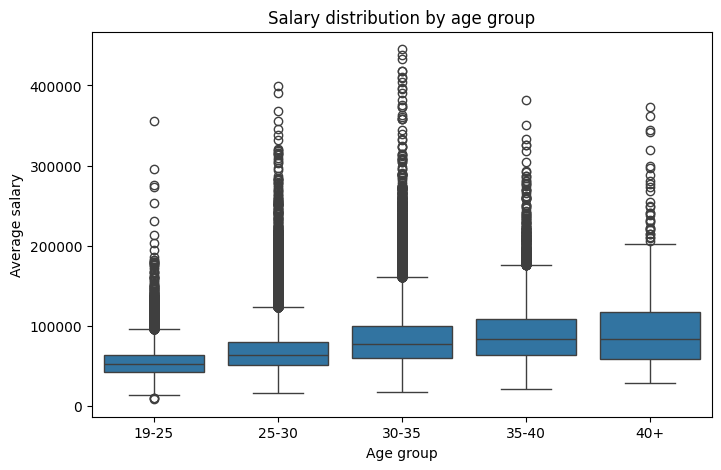

In [75]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='age_group',
    y='average_salary_fact_avg'
)

plt.title(
    'Salary distribution by age group'
)

plt.xlabel(
    'Age group'
)

plt.ylabel(
    'Average salary'
)

plt.show()

H0- распределение заработных плат одинаково во всех возрастных группах
H1- хотя бы одна возрастная группа по распределению заработных плат

In [76]:
from scipy.stats import kruskal

groups = [
    group['average_salary_fact_avg'].values
    for _, group in df.groupby('age_group')
]

stat, p = kruskal(*groups)

print('Statistic:', stat)
print('p-value:', p)

Statistic: 24626.060294562663
p-value: 0.0


/tmp/ipykernel_10078/816295170.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in df.groupby('age_group')


Различия между возрастными группами статистически значимы.


УРОВЕНЬ ОБРАЗОВАНИЯ ВЛИЯЕТ НА ЗАРАБОТНУЮ ПЛАТУ ВЫПУСКНИКОВ


H0: уровень образования не влияет на зарплату.

H1: между уровнями образования существуют статистически значимые различия в заработной плате.

education_level
СПО: специалисты среднего звена              75280
СПО: квалифицированные рабочие и служащие    34617
Бакалавриат, специалитет                     25285
Магистратура                                 13085
Name: count, dtype: int64


,count,mean,median,std
education_level,,,,
Магистратура,13085,106693.84,96702.80,44098.25
"Бакалавриат, специалитет",25285,86738.02,80000.64,32678.35
СПО: специалисты среднего звена,75280,62335.64,58106.93,21193.27
СПО: квалифицированные рабочие и служащие,34617,59682.38,58162.13,19012.17


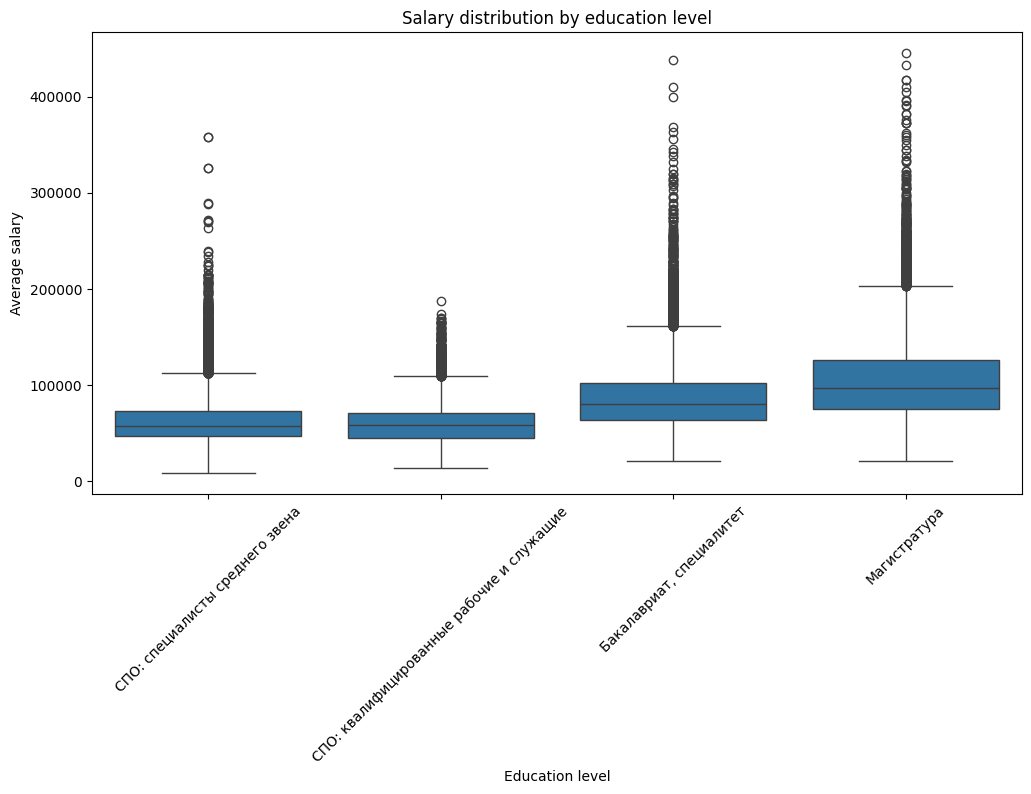

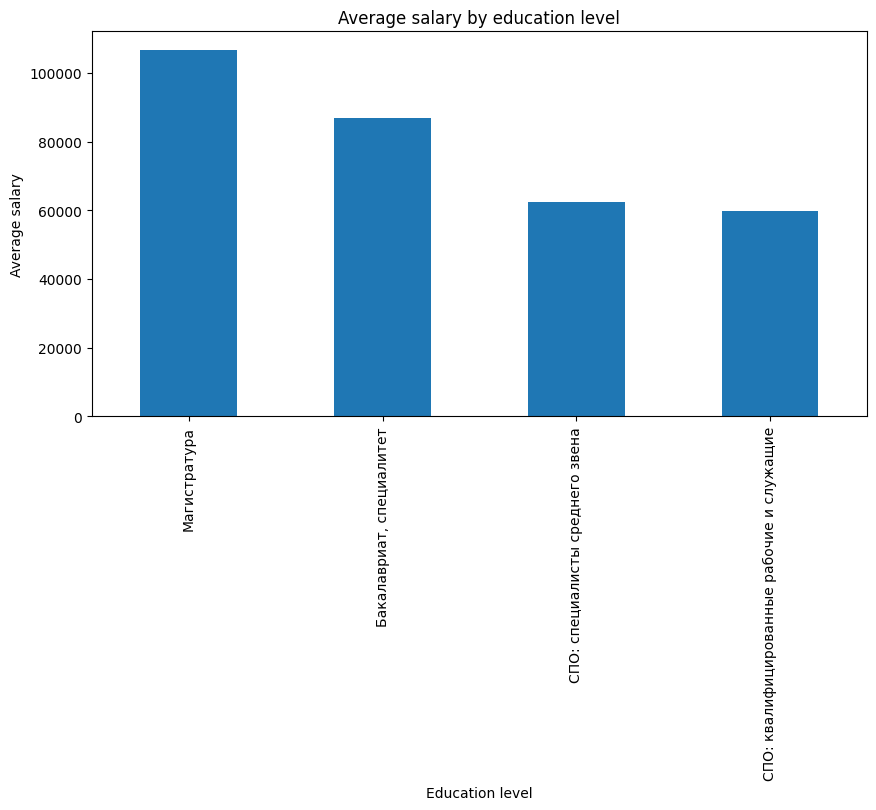

Statistic: 30791.657409231368
p-value: 0.0


In [77]:
# Посмотрим категории

print(
    df['education_level']
    .value_counts()
)

# Средняя зарплата по уровням образования

salary_by_education = (
    df.groupby('education_level')
      ['average_salary_fact_avg']
      .agg([
          'count',
          'mean',
          'median',
          'std'
      ])
      .round(2)
      .sort_values(
          'mean',
          ascending=False
      )
)

display(
    salary_by_education
)

# Boxplot

plt.figure(
    figsize=(12,6)
)

sns.boxplot(
    data=df,
    x='education_level',
    y='average_salary_fact_avg'
)

plt.title(
    'Salary distribution by education level'
)

plt.xlabel(
    'Education level'
)

plt.ylabel(
    'Average salary'
)

plt.xticks(
    rotation=45
)

plt.show()

# Средняя зарплата по уровням образования

plt.figure(
    figsize=(10,5)
)

salary_by_education['mean'].sort_values(
    ascending=False
).plot(
    kind='bar'
)

plt.title(
    'Average salary by education level'
)

plt.xlabel(
    'Education level'
)

plt.ylabel(
    'Average salary'
)

plt.show()

# Статистическая проверка

from scipy.stats import kruskal

groups = [
    group['average_salary_fact_avg'].values
    for _, group
    in df.groupby('education_level')
]

stat, p_value = kruskal(
    *groups
)

print(
    'Statistic:',
    stat
)

print(
    'p-value:',
    p_value
)

PERCENT_EMPLOYED

Уровень трудоустройства связан с заработной платой

count    148267.000000
mean         76.784187
std          13.022027
min           8.462000
25%          69.792000
50%          78.947000
75%          86.000000
max         100.000000
Name: percent_employed, dtype: float64
Spearman correlation: 0.3394
p-value: 0.0000000000


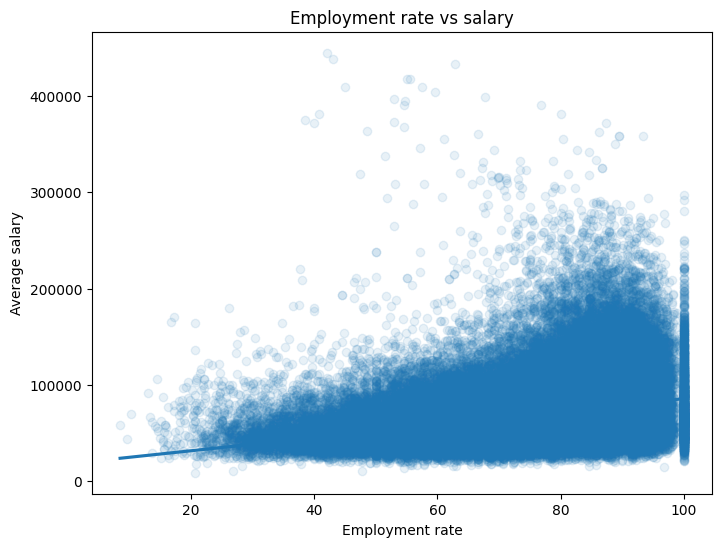

In [78]:
print(
    df['percent_employed']
    .describe()
)

# Корреляция

from scipy.stats import spearmanr

corr, p = spearmanr(
    df['percent_employed'],
    df['average_salary_fact_avg']
)

print(
    f'Spearman correlation: {corr:.4f}'
)

print(
    f'p-value: {p:.10f}'
)

# Scatterplot

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='percent_employed',
    y='average_salary_fact_avg',
    scatter_kws={
        'alpha':0.1
    }
)

plt.title(
    'Employment rate vs salary'
)

plt.xlabel(
    'Employment rate'
)

plt.ylabel(
    'Average salary'
)

plt.show()

In [79]:
df['employment_group'] = pd.cut(
    df['percent_employed'],
    bins=[0,60,70,80,90,100],
    labels=[
        '0-60%',
        '60-70%',
        '70-80%',
        '80-90%',
        '90-100%'
    ]
)

salary_by_employment = (
    df.groupby('employment_group')
      ['average_salary_fact_avg']
      .agg([
          'count',
          'mean',
          'median',
          'std'
      ])
      .round(2)
)

display(
    salary_by_employment
)

/tmp/ipykernel_10078/1617816061.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('employment_group')


,count,mean,median,std
employment_group,,,,
0-60%,15978,55534.01,50673.70,24417.48
60-70%,22043,59603.86,55750.86,22976.78
70-80%,42017,66172.98,61994.52,25072.81
80-90%,49260,76678.65,70657.39,31084.98
90-100%,18969,83776.71,76471.87,35766.96


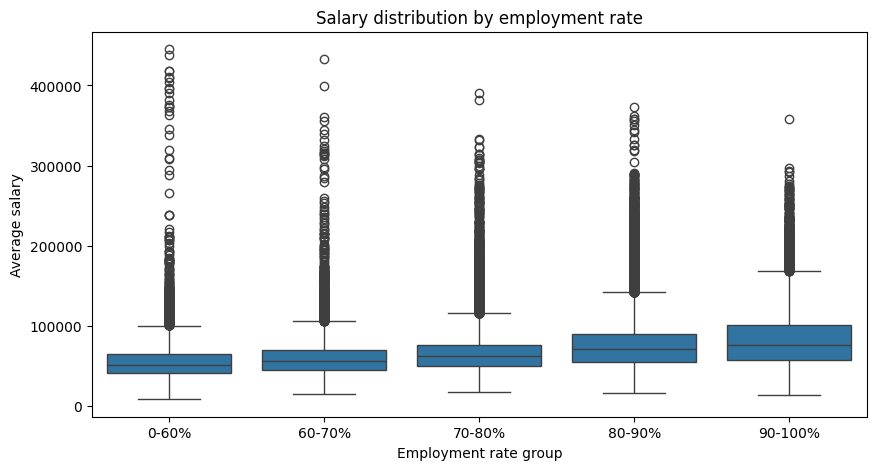

In [80]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='employment_group',
    y='average_salary_fact_avg'
)

plt.title(
    'Salary distribution by employment rate'
)

plt.xlabel(
    'Employment rate group'
)

plt.ylabel(
    'Average salary'
)

plt.show()

In [81]:
from scipy.stats import kruskal

groups = [
    group['average_salary_fact_avg'].values
    for _, group in df.groupby('employment_group')
]

stat, p = kruskal(
    *groups
)

print(
    'Statistic:',
    stat
)

print(
    'p-value:',
    p
)

Statistic: 16399.362921809487
p-value: 0.0


/tmp/ipykernel_10078/125612163.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, group in df.groupby('employment_group')


Чем выше доля трудоустроенных, тем выше их средняя зп

H0 - отвергается, различия между группами статистически значимы

ПОЛ ВЛИЯЕТ НА ЗП

,count,mean,median,std
gender,,,,
Женский,44626,57338.21,51470.00,23885.20
Мужской,46908,82308.05,75716.98,32202.79


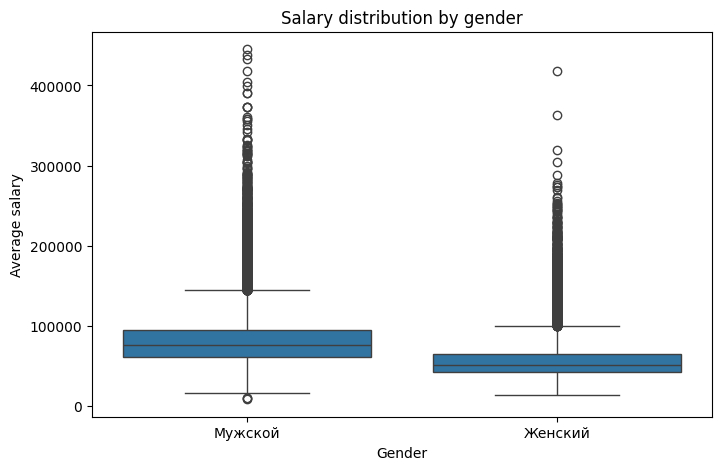

Statistic: 1637813584.0
p-value: 0.0


In [82]:
df_gender = df[
    df['gender'] != 'Всего'
].copy()

df_gender = (
    df[
        df['gender'] != 'Всего'
    ]
    .copy()
)

salary_by_gender = (
    df_gender
    .groupby('gender')
    ['average_salary_fact_avg']
    .agg([
        'count',
        'mean',
        'median',
        'std'
    ])
    .round(2)
)

display(
    salary_by_gender
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_gender,
    x='gender',
    y='average_salary_fact_avg'
)

plt.title(
    'Salary distribution by gender'
)

plt.xlabel(
    'Gender'
)

plt.ylabel(
    'Average salary'
)

plt.show()

from scipy.stats import mannwhitneyu

male_salary = (
    df_gender[
        df_gender['gender'] == 'Мужской'
    ]
    ['average_salary_fact_avg']
)

female_salary = (
    df_gender[
        df_gender['gender'] == 'Женский'
    ]
    ['average_salary_fact_avg']
)

stat, p = mannwhitneyu(
    male_salary,
    female_salary,
    alternative='two-sided'
)

print(
    'Statistic:',
    stat
)

print(
    'p-value:',
    p
)

t-критерий Стьюдента

график distribution



Различия между мужскими и женскими группами статистически значимые


В исследуемых группах выпускников, агрегированных по полу, наблюдаются статистически значимые различия в уровне заработной платы. Средние и медианные значения заработной платы для мужских групп превышают соответствующие показатели для женских групп.

РЕГИОН ВЛИЯЕТ НА ЗП

,count,mean,median,std
object_name,,,,
Чукотский автономный округ,59,131726.49,127247.93,27032.33
Магаданская область,236,112474.01,113667.74,29063.05
Москва,9362,110480.10,98601.27,47879.07
Ямало-Ненецкий автономный округ,378,102913.75,95421.84,31831.60
Камчатский край,450,100167.93,96653.97,27507.71
Ханты-Мансийский автономный округ — Югра,1387,92625.35,87196.10,31306.71
Сахалинская область,443,91811.56,86368.15,29101.36
Республика Саха (Якутия),1441,90684.18,87166.39,24795.37
Санкт-Петербург,5247,89217.91,81418.89,35078.61


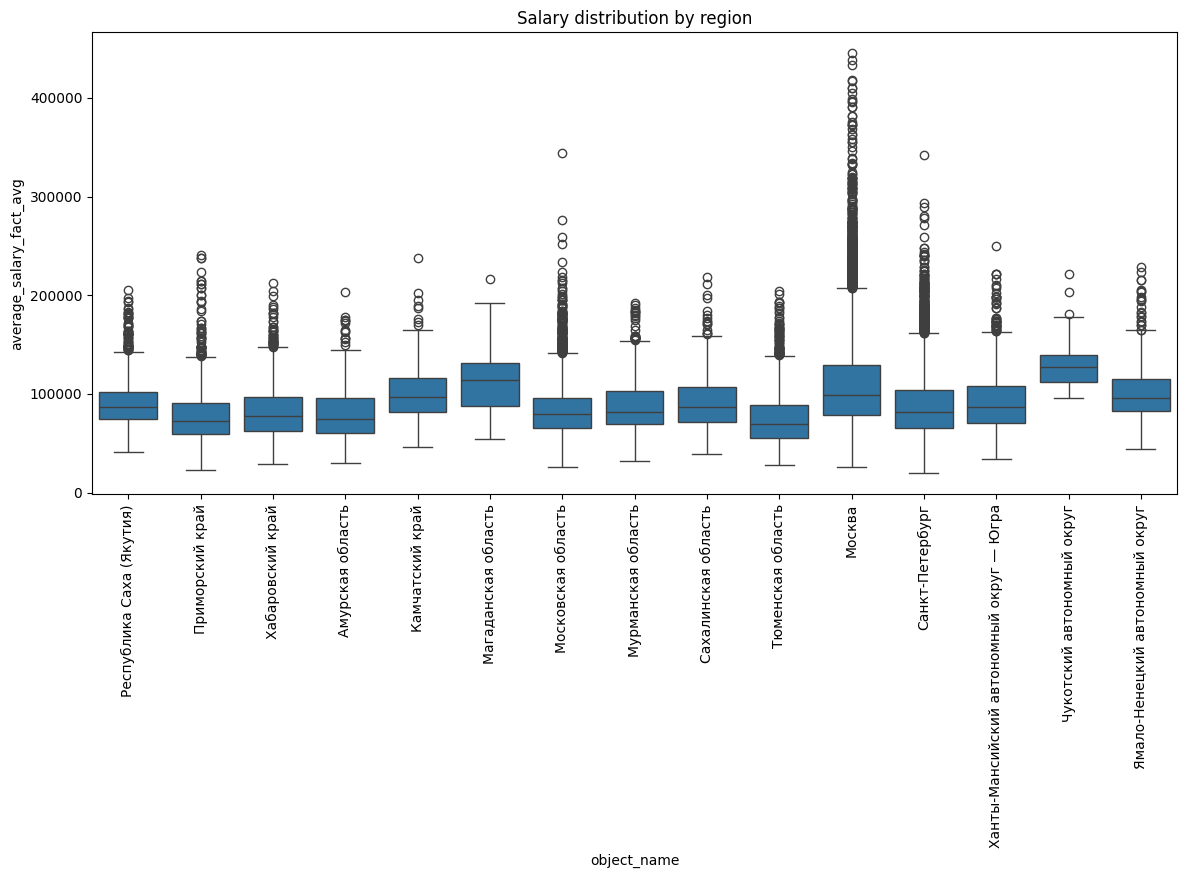

Statistic: 31950.850142968342
p-value: 0.0


In [83]:
salary_by_region = (
    df.groupby('object_name')
      ['average_salary_fact_avg']
      .agg([
          'count',
          'mean',
          'median',
          'std'
      ])
      .round(2)
      .sort_values(
          'mean',
          ascending=False
      )
)

display(
    salary_by_region.head(15)
)

top_regions = (
    salary_by_region
    .head(15)
    .index
)

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df[
        df['object_name'].isin(
            top_regions
        )
    ],
    x='object_name',
    y='average_salary_fact_avg'
)

plt.xticks(rotation=90)

plt.title(
    'Salary distribution by region'
)

plt.show()

from scipy.stats import kruskal

groups = [
    group['average_salary_fact_avg'].values
    for _, group
    in df.groupby('object_name')
]

stat, p = kruskal(*groups)

print(
    'Statistic:',
    stat
)

print(
    'p-value:',
    p
)

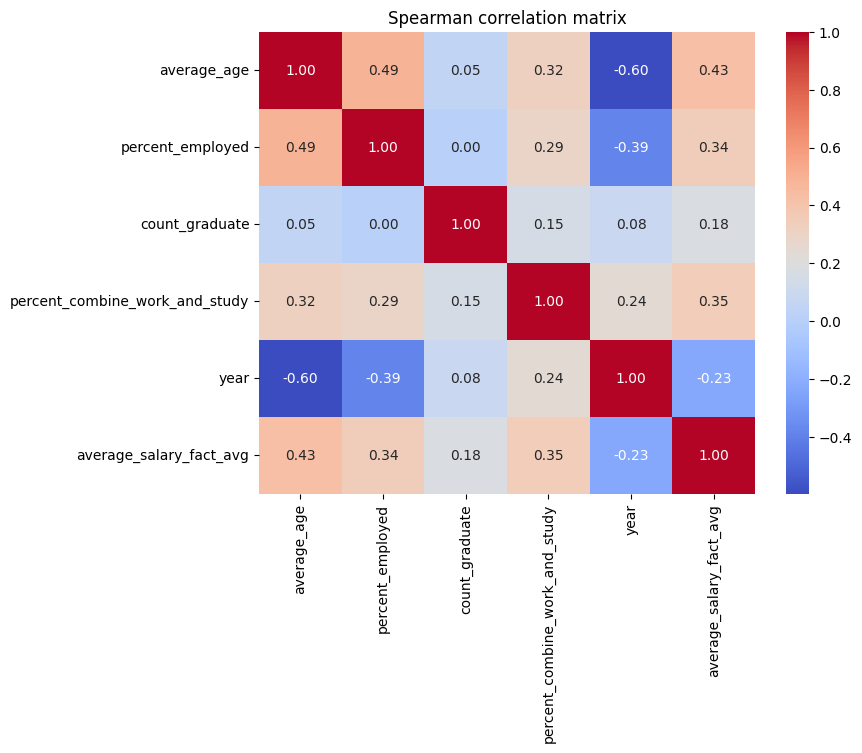

In [84]:
numeric_features = [
    'average_age',
    'percent_employed',
    'count_graduate',
    'percent_combine_work_and_study',
    'year',
    'average_salary_fact_avg'
]

corr_matrix = (
    df[numeric_features]
    .corr(method='spearman')
)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title(
    'Spearman correlation matrix'
)

plt.show()

In [85]:
model_df = df.copy()

features = [
    'average_age',
    'percent_employed',
    'count_graduate',
    'percent_combine_work_and_study',
    'year',
    'gender',
    'education_level',
    'object_name'
]

target = 'average_salary_fact_avg'

model_df = df[
    features + [target]
].copy()

print(model_df.shape)

(148267, 9)


In [86]:
model_df = pd.get_dummies(
    model_df,
    columns=[
        'gender',
        'education_level',
        'object_name'
    ],
    drop_first=True
)

print(model_df.shape)

(148267, 100)


# Гипотезы по матрице

ГИПОТЕЗА
H0:
Между средним возрастом выпускников и средней заработной платой отсутствует статистически значимая связь.

H1:
Между средним возрастом выпускников и средней заработной платой существует статистически значимая положительная связь.

In [87]:
# Проверка гипотезы

corr, p_value = spearmanr(
    df['average_age'],
    df['average_salary_fact_avg']
)

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p_value:.5f}")

Spearman correlation: 0.431
p-value: 0.00000


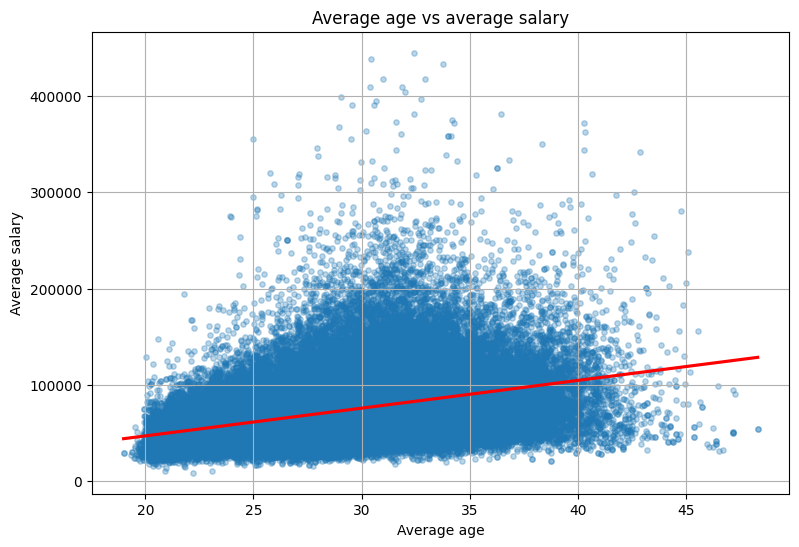

In [88]:
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x='average_age',
    y='average_salary_fact_avg',
    scatter_kws={
        'alpha':0.3,
        's':15
    },
    line_kws={
        'color':'red'
    }
)

plt.title(
    'Average age vs average salary'
)

plt.xlabel(
    'Average age'
)

plt.ylabel(
    'Average salary'
)

plt.grid(True)

plt.show()

Если бы возаст практически полностью определял зарплату, то точки лежали бы почти на одной линии

Максимальные зарплаты наблюдаются примерно у людей 29-34 лет. После этого возраст продолжает расти, а самые большие зарплаты становятся реже.

Минимальные зарплаты почти одинаковы независимо от возраста.

Average_age ------- Year = -0,60

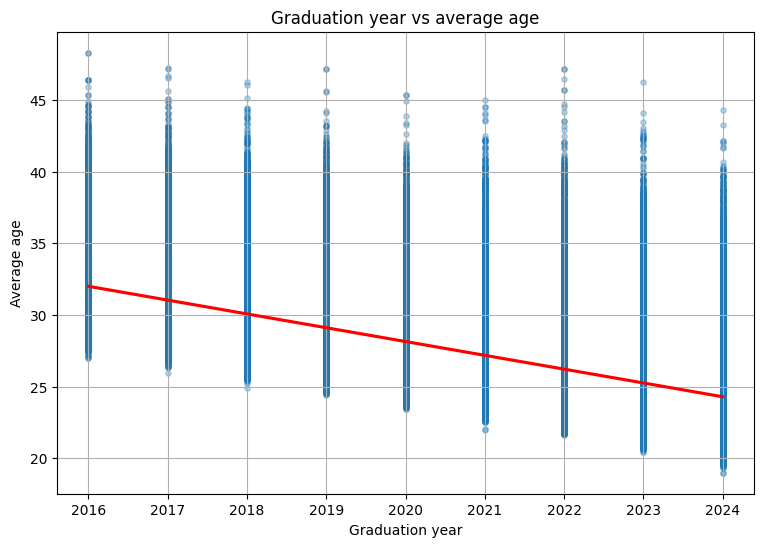

In [89]:
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x='year',
    y='average_age',
    scatter_kws={
        'alpha':0.3,
        's':15
    },
    line_kws={
        'color':'red'
    }
)

plt.title("Graduation year vs average age")

plt.xlabel("Graduation year")

plt.ylabel("Average age")

plt.grid(True)

plt.show()

Отрицательная зависимость между годом выпуска и средним возрастом выпускников. По мере увеличения года выпуска средний возраст снижается, что отражается отрицательным наклоном линии регрессии.

Более поздние выпуски представлены преимущественно более молодыми выпускниками, тогда как среди более ранних выпусков средний возраст выше.

In [90]:
corr, p = spearmanr(
    df["year"],
    df["average_age"]
)

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p:.5f}")

Spearman correlation: -0.598
p-value: 0.00000


Полученное значение p-value значительно меньше уровня значимости 0.05, поэтому нулевая гипотеза об отсутствии связи отвергается.

Таким образом, статистический анализ подтверждает, что более ранние выпуски характеризуются более высоким средним возрастом выпускников.

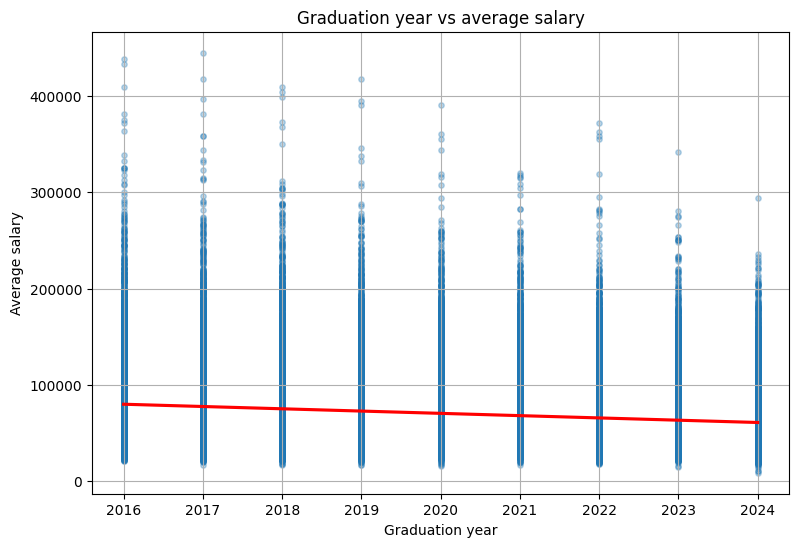

In [91]:
# Зарплата относительно года выпуска
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x='year',
    y='average_salary_fact_avg',
    scatter_kws={
        'alpha':0.3,
        's':15
    },
    line_kws={
        'color':'red'
    }
)

plt.title("Graduation year vs average salary")

plt.xlabel("Graduation year")

plt.ylabel("Average salary")

plt.grid(True)

plt.show()

Построенный график показывает наличие отрицательной зависимости между годом выпуска и средней заработной платой выпускников. Линия регрессии имеет отрицательный наклон, что свидетельствует о постепенном снижении средней заработной платы для более поздних выпусков.

При этом разброс наблюдений остается достаточно большим, что указывает на влияние дополнительных факторов, определяющих уровень заработной платы. Несмотря на это, общий нисходящий тренд сохраняется.

Кроме того, можно заметить, что наиболее высокие значения заработной платы значительно чаще встречаются среди более ранних выпусков (2016–2019 гг.), тогда как среди выпускников последних лет такие значения наблюдаются существенно реже.

Дополнительный анализ позволил объяснить ранее обнаруженную положительную связь между средним возрастом выпускников и средней заработной платой. Было установлено, что средний возраст тесно связан с годом выпуска (ρ = -0.598): выпускники более ранних лет имеют более высокий средний возраст. Одновременно наблюдается отрицательная зависимость между годом выпуска и уровнем заработной платы, что свидетельствует о более высоких доходах выпускников ранних выпусков. Полученные результаты позволяют предположить, что положительная связь между возрастом и заработной платой может быть обусловлена не только возрастом как таковым, но и накопленным профессиональным опытом, который естественным образом увеличивается с течением времени после окончания обучения.

# ГИПОТЕЗА 2

H0

Между долей трудоустроенных выпускников и средней заработной платой отсутствует статистически значимая связь.

H1

Между долей трудоустроенных выпускников и средней заработной платой существует статистически значимая положительная связь.

In [92]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    df["percent_employed"],
    df["average_salary_fact_avg"]
)

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p:.5f}")

Spearman correlation: 0.339
p-value: 0.00000


Полученное значение свидетельствует о статистически значимой положительной корреляции средней силы между долей трудоустроенных выпускников и средней заработной платой.

Поскольку значение p-value значительно меньше уровня значимости 0.05, нулевая гипотеза отвергается.

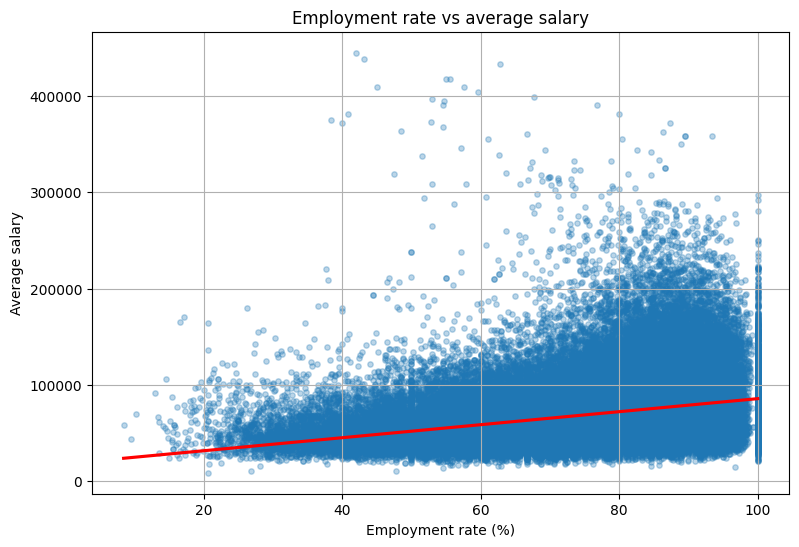

In [93]:
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x="percent_employed",
    y="average_salary_fact_avg",
    scatter_kws={
        "alpha":0.3,
        "s":15
    },
    line_kws={
        "color":"red"
    }
)

plt.title("Employment rate vs average salary")

plt.xlabel("Employment rate (%)")

plt.ylabel("Average salary")

plt.grid(True)

plt.show()

Красная линия регрессии имеет восходящий наклон, что свидетельствует о том, что при увеличении доли трудоустроенных выпускников средняя заработная плата также имеет тенденцию к росту.

Облако точек достаточно широкое, особенно при высоких значениях доли трудоустроенных (80–100%). Это означает, что даже при одинаковом уровне занятости заработная плата может существенно различаться. Следовательно, уровень трудоустройства является не единственным фактором, определяющим величину заработной платы выпускников.

средний возраст выпускников объясняет различия в зарплате даже лучше, чем сам процент трудоустройства.

# Гипотеза 3

H0

Между долей выпускников, совмещавших работу с учебой, и средней заработной платой отсутствует статистически значимая связь.

H1

Между долей выпускников, совмещавших работу с учебой, и средней заработной платой существует статистически значимая положительная связь.

Логика размышления, если подтвердится:
Более высокая доля студентов, которые работали еще во время обучения, выше их последующая средняя заработная плата.

In [94]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    df["percent_combine_work_and_study"],
    df["average_salary_fact_avg"]
)

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p:.5f}")

Spearman correlation: 0.347
p-value: 0.00000


Полученный коэффициент свидетельствует о статистически значимой положительной корреляции средней силы между долей выпускников, совмещавших работу с учебой, и средней заработной платой.

Поскольку значение p-value значительно меньше уровня значимости 0.05, нулевая гипотеза отвергается.

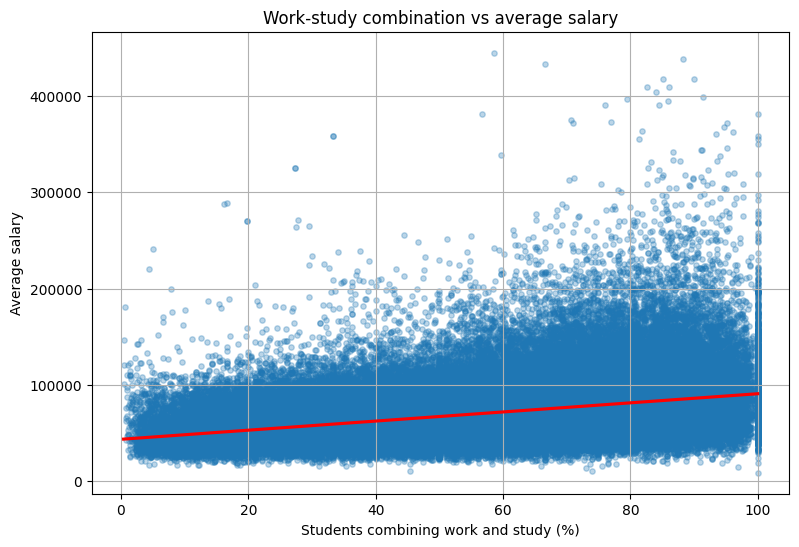

In [95]:
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x="percent_combine_work_and_study",
    y="average_salary_fact_avg",
    scatter_kws={
        "alpha":0.3,
        "s":15
    },
    line_kws={
        "color":"red"
    }
)

plt.title("Work-study combination vs average salary")

plt.xlabel("Students combining work and study (%)")

plt.ylabel("Average salary")

plt.grid(True)

plt.show()

На графике наблюдается положительная зависимость между долей выпускников, совмещавших работу с учебой, и средней заработной платой. Линия регрессии имеет восходящий наклон, что указывает на тенденцию увеличения средней заработной платы по мере роста доли студентов, работавших во время обучения. Точки распределены достаточно широко относительно линии регрессии. Это говорит о том, что влияние данного фактора нельзя считать определяющим: при одинаковой доле студентов, совмещавших работу с учебой, уровень средней заработной платы может значительно различаться. Следовательно, на уровень оплаты труда выпускников оказывают влияние и другие факторы.

Результаты анализа позволяют сделать вывод о том, что гипотеза H1 подтверждается.

Между долей выпускников, совмещавших работу с учебой, и средней заработной платой существует статистически значимая положительная связь. Это позволяет предположить, что наличие практического опыта работы в период обучения положительно отражается на последующем уровне доходов выпускников. Однако умеренная величина коэффициента корреляции (ρ=0.347) свидетельствует о том, что уровень заработной платы определяется не только опытом совмещения работы с учебой, но и другими факторами.

# Гипотеза 4

H0

Между средним возрастом выпускников и долей выпускников, совмещавших работу с учебой, отсутствует статистически значимая связь.

H1

Между средним возрастом выпускников и долей выпускников, совмещавших работу с учебой, существует статистически значимая положительная связь.

Если гипотеза подтвердится, это может свидетельствовать о том, что более взрослые студенты чаще совмещают обучение с работой, приобретая профессиональный опыт еще во время учебы. Такой опыт, в свою очередь, может быть одной из причин более высокого уровня заработной платы после окончания обучения.

In [96]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    df["average_age"],
    df["percent_combine_work_and_study"]
)

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p:.5f}")

Spearman correlation: 0.320
p-value: 0.00000


Полученный коэффициент свидетельствует о наличии статистически значимой положительной корреляции средней силы между средним возрастом выпускников и долей выпускников, совмещавших работу с учебой.

Так как значение p-value значительно меньше уровня значимости 0.05, нулевая гипотеза отвергается.

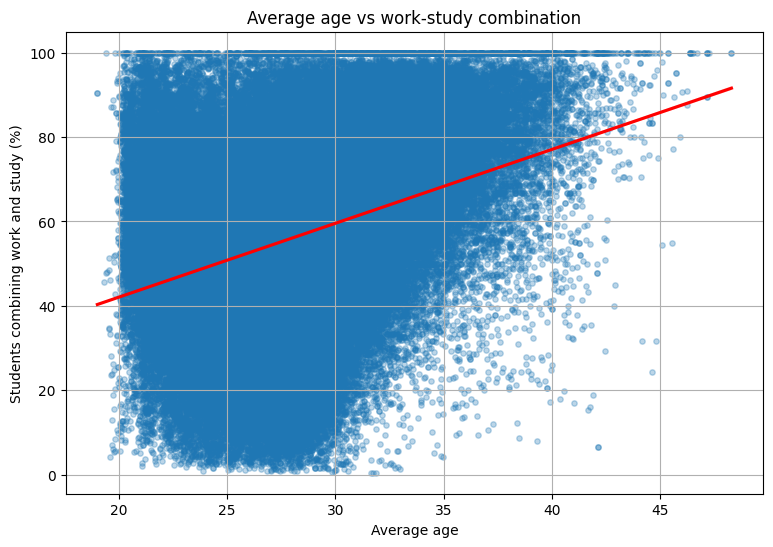

In [97]:
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x="average_age",
    y="percent_combine_work_and_study",
    scatter_kws={
        "alpha":0.3,
        "s":15
    },
    line_kws={
        "color":"red"
    }
)

plt.title("Average age vs work-study combination")

plt.xlabel("Average age")

plt.ylabel("Students combining work and study (%)")

plt.grid(True)

plt.show()

Линия регрессии имеет выраженный восходящий наклон, что свидетельствует о том, что с увеличением среднего возраста выпускников возрастает доля студентов, работавших в период обучения. Несмотря на значительный разброс наблюдений, общая тенденция прослеживается достаточно отчетливо. Это позволяет предположить, что более взрослые студенты действительно чаще совмещают обучение с трудовой деятельностью.

Между средним возрастом выпускников и долей студентов, совмещавших работу с учебой, существует статистически значимая положительная связь. Это позволяет предположить, что более взрослые студенты чаще приобретают профессиональный опыт еще в период обучения. Такой опыт может являться одним из факторов, способствующих более высокому уровню заработной платы после окончания образовательной программы.

# Гипотеза 5

H0

Между долей выпускников, совмещавших работу с учебой, и долей трудоустроенных выпускников отсутствует статистически значимая связь.

H1

Между долей выпускников, совмещавших работу с учебой, и долей трудоустроенных выпускников существует статистически значимая положительная связь.

Если выпускники начинают работать еще во время обучения, они приобретают практический опыт, формируют профессиональные навыки и деловые контакты. Поэтому можно ожидать, что после окончания университета они будут чаще успешно трудоустраиваться.

In [98]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    df["percent_combine_work_and_study"],
    df["percent_employed"]
)

print(f"Spearman correlation: {corr:.3f}")
print(f"p-value: {p:.5f}")

Spearman correlation: 0.292
p-value: 0.00000


Полученные результаты подтверждают предположение о том, что опыт работы во время обучения способствует более успешному трудоустройству после окончания университета. Вероятно, практический опыт, профессиональные навыки и деловые контакты, приобретенные в период обучения, повышают конкурентоспособность выпускников на рынке труда.

Хотя сила связи является умеренной (ρ = 0.292), она статистически значима и согласуется с логикой исследования.

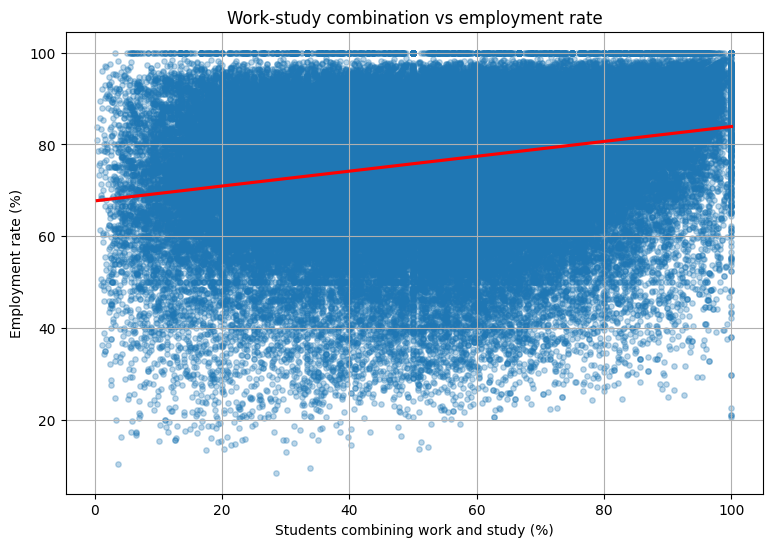

In [99]:
plt.figure(figsize=(9,6))

sns.regplot(
    data=df,
    x="percent_combine_work_and_study",
    y="percent_employed",
    scatter_kws={
        "alpha":0.3,
        "s":15
    },
    line_kws={
        "color":"red"
    }
)

plt.title("Work-study combination vs employment rate")

plt.xlabel("Students combining work and study (%)")

plt.ylabel("Employment rate (%)")

plt.grid(True)

plt.show()

С увеличением доли студентов, совмещавших работу и учебу, наблюдается увеличение доли трудоустроенных выпускников. Линия регрессии имеет положительный наклон, что подтверждает направление выявленной зависимости. При этом облако точек остается достаточно широким, поэтому зависимость нельзя считать сильной. Это означает, что на уровень трудоустройства влияют и другие факторы, однако совмещение работы с учебой является одним из статистически значимых факторов.

То есть возраст сам по себе, вероятно, не является непосредственной причиной более высокой зарплаты. Скорее, более взрослые студенты чаще работают во время обучения, накопленный опыт повышает вероятность трудоустройства, а успешное трудоустройство уже связано с более высокой заработной платой.

# Гипотеза 6

H0

Средняя заработная плата выпускников не зависит одновременно от среднего возраста, доли трудоустроенных выпускников и доли выпускников, совмещавших работу с учебой.

H1

Средняя заработная плата выпускников зависит хотя бы от одного из указанных факторов.

In [100]:
from sklearn.linear_model import LinearRegression

X = df[
    [
        "average_age",
        "percent_employed",
        "percent_combine_work_and_study"
    ]
]

y = df["average_salary_fact_avg"]

model = LinearRegression()

model.fit(X, y)

print("Intercept:", model.intercept_)
print()

for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")

print()
print(f"R² = {model.score(X, y):.3f}")

Intercept: -21894.58089767254

average_age: 2011.26
percent_employed: 237.26
percent_combine_work_and_study: 307.11

R² = 0.225


In [101]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
0,average_age,2011.257906
2,percent_combine_work_and_study,307.105377
1,percent_employed,237.257865


Построенная модель множественной линейной регрессии показала, что средняя заработная плата выпускников связана одновременно с рассматриваемыми факторами — средним возрастом выпускников, долей трудоустроенных выпускников и долей выпускников, совмещавших работу с учебой.

Коэффициент детерминации модели составил 0,225
То есть, выбранные факторы объясняют около 22,5 % изменчивости средней заработной платы выпускников, тогда как оставшаяся часть обусловлена другими характеристиками, не включенными в модель (направление подготовки, регион, уровень университета, отрасль трудоустройства, экономическая ситуация и др.).

Следовательно, нулевая гипотеза отвергается, а альтернативная принимается.

Все коэффициенты положительные, что свидетельствует о положительном влиянии рассматриваемых факторов на уровень средней заработной платы.

При прочих равных условиях:

- увеличение среднего возраста выпускников на 1 год сопровождается увеличением средней заработной платы примерно на 2011 рублей;

- увеличение доли студентов, совмещавших работу и учебу, на 1 процентный пункт связано с увеличением средней заработной платы примерно на 307 рублей;

- увеличение доли трудоустроенных выпускников на 1 процентный пункт сопровождается ростом средней заработной платы примерно на 237 рублей.

In [102]:
import statsmodels.api as sm

X = df[
    [
        "average_age",
        "percent_employed",
        "percent_combine_work_and_study"
    ]
]

X = sm.add_constant(X)

y = df["average_salary_fact_avg"]

model = sm.OLS(y, X).fit()

print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     average_salary_fact_avg   R-squared:                       0.225
Model:                                 OLS   Adj. R-squared:                  0.225
Method:                      Least Squares   F-statistic:                 1.437e+04
Date:                     Wed, 01 Jul 2026   Prob (F-statistic):               0.00
Time:                             13:49:46   Log-Likelihood:            -1.7189e+06
No. Observations:                   148267   AIC:                         3.438e+06
Df Residuals:                       148263   BIC:                         3.438e+06
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

Проведенный корреляционный и регрессионный анализ показал, что среди новых признаков, добавленных в версию 2.0 набора данных (average_age и percent_combine_work_and_study), оба оказывают статистически значимое влияние на среднюю заработную плату выпускников. При этом наиболее сильная связь была выявлена для среднего возраста выпускников, а показатель совмещения работы и учебы позволил объяснить возможный механизм формирования более высокой заработной платы через накопление профессионального опыта и повышение уровня последующего трудоустройства.

# Изменения по графикам

Зарплата по годам

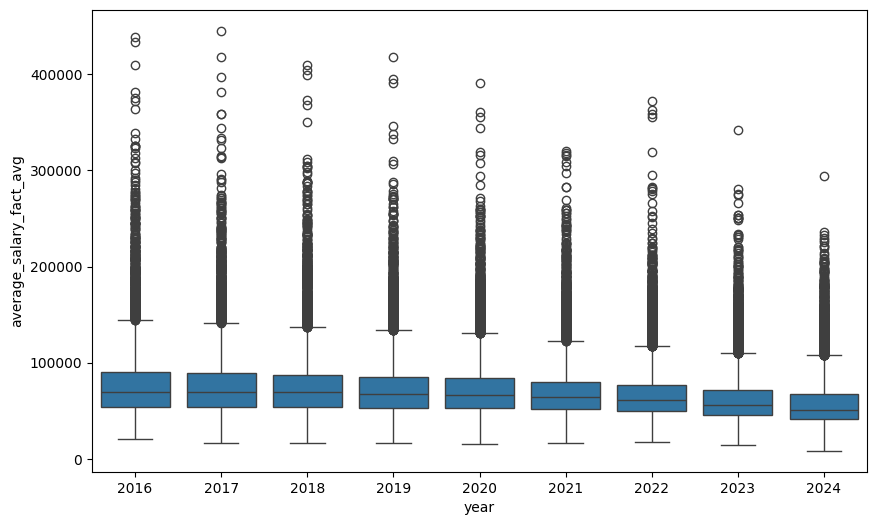

In [103]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='year',
    y='average_salary_fact_avg'
)

plt.show()

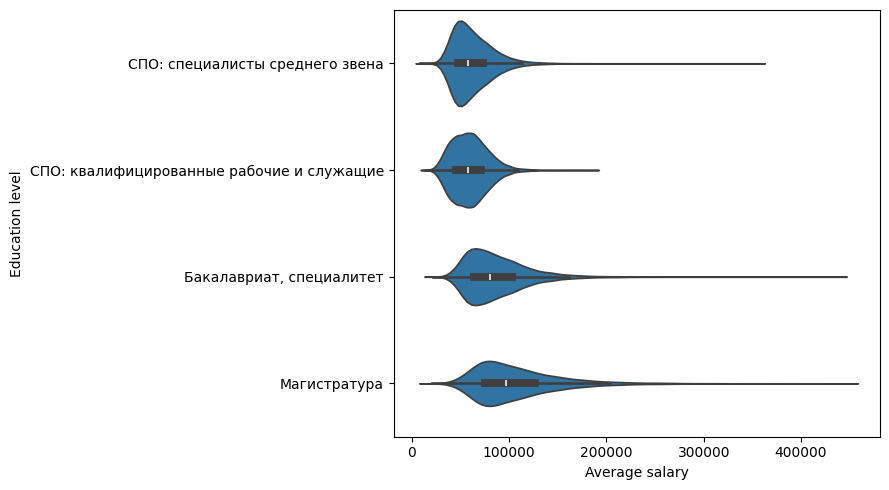

In [104]:
#Violin Plot
plt.figure(figsize=(9,5))

sns.violinplot(
    data=df,
    y="education_level",
    x="average_salary_fact_avg"
)

plt.xlabel("Average salary")
plt.ylabel("Education level")

plt.tight_layout()
plt.show()

По мере повышения уровня образования распределение заработной платы смещается вправо, что свидетельствует об увеличении типичного уровня доходов выпускников. При этом во всех группах наблюдаются отдельные выпускники с очень высокой заработной платой, однако основная масса наблюдений сосредоточена значительно ниже этих значений.

1. Levene test

Проверяет равенство дисперсий между группами.

H0: дисперсии одинаковы.

In [105]:
from scipy.stats import levene

groups = [
    group["average_salary_fact_avg"].dropna().values
    for _, group in df.groupby("education_level")
]

stat, p = levene(*groups)

print(f"Levene statistic = {stat:.3f}")
print(f"p-value = {p:.5f}")

Levene statistic = 4207.545
p-value = 0.00000


Вывод: дисперсии заработной платы между уровнями образования статистически значимо различаются.

Тест Левена показал статистически значимые различия дисперсий средней заработной платы между уровнями образования (Levene = 4207.545, p < 0.001). Следовательно, предположение об однородности дисперсий не выполняется. Это свидетельствует о том, что вариативность заработной платы существенно отличается в зависимости от уровня образования выпускников.

2. Kruskal–Wallis

Поскольку тест Левена показал неоднородность дисперсий, а распределение средней заработной платы характеризуется асимметрией и наличием большого количества выбросов (что было выявлено при анализе Violin Plot), для сравнения уровня заработной платы между группами образования используется непараметрический критерий Краскела—Уоллиса.

H0

Распределение средней заработной платы одинаково во всех уровнях образования.

H1

Хотя бы один уровень образования отличается по распределению средней заработной платы.

In [106]:
from scipy.stats import kruskal

groups = [
    group["average_salary_fact_avg"].dropna().values
    for _, group in df.groupby("education_level")
]

stat, p = kruskal(*groups)

print(f"Kruskal statistic = {stat:.3f}")
print(f"p-value = {p:.5f}")

Kruskal statistic = 30791.657
p-value = 0.00000


# Гипотеза 7

Существует ли связь между полом выпускников и уровнем образования?

H0

Пол выпускников не связан с уровнем образования. Распределение мужчин и женщин одинаково для всех уровней образования.

H1

Между полом выпускников и уровнем образования существует статистически значимая связь.

In [107]:
pd.crosstab(
    df["education_level"],
    df["gender"]
)

gender,Всего,Женский,Мужской
education_level,,,
"Бакалавриат, специалитет",8815,8368,8102
Магистратура,4854,4327,3904
СПО: квалифицированные рабочие и служащие,14487,7488,12642
СПО: специалисты среднего звена,28577,24443,22260


ввиду наличия "всего" логично для Кси-квадрата использовать только "Женский" и "Мужской", иначе тест будет некорректным!

Абсолютные числа сравнивать неудобно, потому что группы образования разного размера


In [108]:
pd.crosstab(
    df["education_level"],
    df["gender"],
    normalize="index"
).round(3) * 100

gender,Всего,Женский,Мужской
education_level,,,
"Бакалавриат, специалитет",34.9,33.1,32.0
Магистратура,37.1,33.1,29.8
СПО: квалифицированные рабочие и служащие,41.8,21.6,36.5
СПО: специалисты среднего звена,38.0,32.5,29.6


<Figure size 900x600 with 0 Axes>

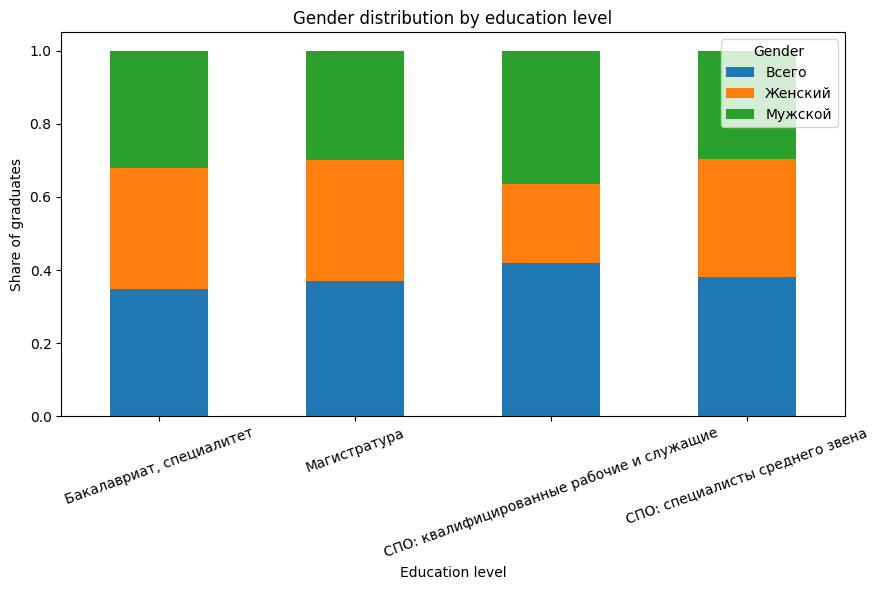

In [109]:
plt.figure(figsize=(9,6))

pd.crosstab(
    df["education_level"],
    df["gender"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True,
    figsize=(9,6)
)

plt.title("Gender distribution by education level")
plt.xlabel("Education level")
plt.ylabel("Share of graduates")

plt.xticks(rotation=20)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

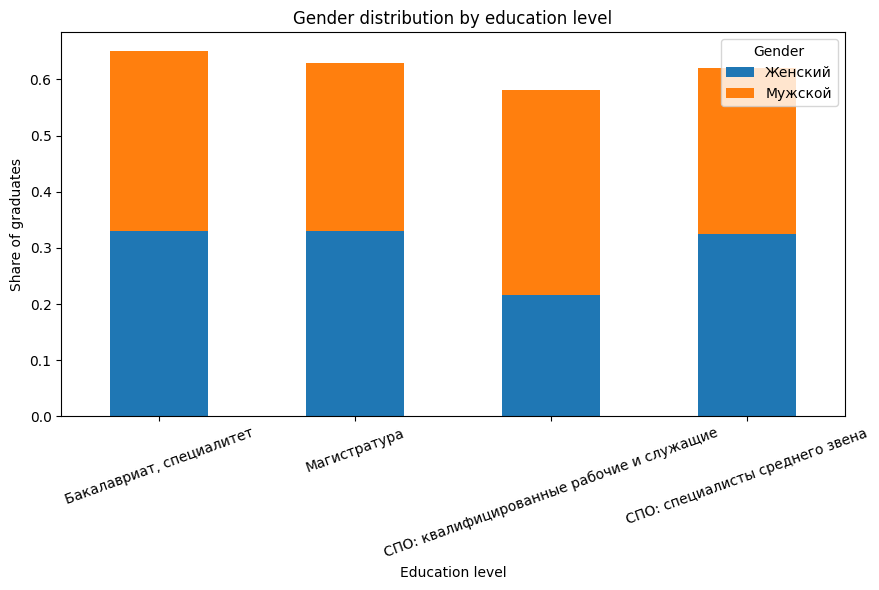

In [111]:
plt.figure(figsize=(9,6))

pd.crosstab(
    df["education_level"],
    df["gender"],
    normalize="index"
)[["Женский", "Мужской"]].plot(
    kind="bar",
    stacked=True,
    figsize=(9,6)
)

plt.title("Gender distribution by education level")
plt.xlabel("Education level")
plt.ylabel("Share of graduates")

plt.xticks(rotation=20)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

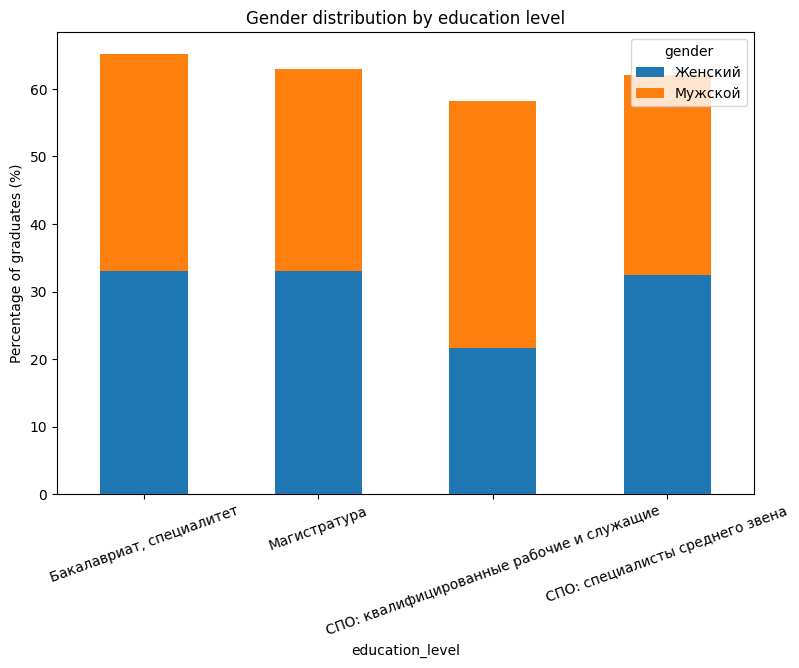

In [112]:
(
    pd.crosstab(
        df["education_level"],
        df["gender"],
        normalize="index"
    )[["Женский", "Мужской"]]
    * 100
).plot(
    kind="bar",
    stacked=True,
    figsize=(9,6)
)

plt.ylabel("Percentage of graduates (%)")
plt.title("Gender distribution by education level")

plt.xticks(rotation=20)

plt.show()

1. Во всех уровнях образования присутствуют оба пола
2. Наибольшая доля мужчин наблюдается среди выпускников СПО
3. Среди Баков, Спец, Магов, СПО распределение полов более равномерно
4. Наибольшая доля мужчин наблюдается среди выпускников СПО по направлению "квалифицированные рабочие и служащие"

In [110]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["education_level"],
    df["gender"]
)

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square = {chi2:.3f}")
print(f"Degrees of freedom = {dof}")
print(f"p-value = {p:.5f}")

Chi-square = 1655.498
Degrees of freedom = 6
p-value = 0.00000


Критерий χ² показал статистически значимую связь между полом выпускников и уровнем образования (p < 0.001). Следовательно, нулевая гипотеза отвергается. Распределение мужчин и женщин различается между уровнями образования.